# Entropy Analysis — Stratification Strategies

Compares two transcript stratification strategies using predictive entropy (H_pred):
1. **Overall thresholds**: 10th / 90th percentile cutoffs applied to all transcripts.
2. **Class-separated thresholds**: Same percentile cutoffs applied separately within coding vs lncRNA transcripts.

**High-entropy criterion**: A transcript is in the *high* group only if **both** H_pred ≥ 90th percentile **and** I_BALD ≥ 90th percentile (model disagreement confirms high uncertainty).

For each strategy the notebook shows:
- Histogram of H_pred by class (context)
- H_pred vs I_BALD scatter coloured by entropy group
- Balanced accuracy across a range of thresholds
- Top-10 univariate feature tests after cluster-based de-duplication for each relevant group comparison

Input: `results/{DATASET}/uncertainty_analysis/{DATASET}_uncertainty_analysis.tsv`

In [ ]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.metrics import balanced_accuracy_score
from statsmodels.stats.multitest import multipletests

np.random.seed(42)

sys.path.insert(0, "/mnt/cbib/LNClassifier/paper/workflow")
from utils.features import filter_feature_columns, get_probabilities, remove_constant_features
from utils.parsing import load_tables
from utils.entropy import load_dataset, load_additional_features
import utils.plotting

sns.set_theme(style='ticks', context='paper')
plt.rcParams['pdf.fonttype'] = 42

print('✓ Imports OK')

✓ Imports OK


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATASET    = 'gencode.v47.common.cdhit.cv'
BASEDIR    = Path('/mnt/cbib/LNClassifier/paper')

LOW_TH     = 10   # percentile below which → 'low' entropy
HIGH_TH    = 90   # percentile above which → 'high' entropy
FDR_METHOD = 'fdr_bh'
FDR_ALPHA  = 0.01

CLUSTER_FILE = (BASEDIR /
    f'results/{DATASET}/features/clustering/feature_clusters_at_distances.csv')
CLUSTER_DIST = 'cluster_0.25'

FIGURE_DIR = BASEDIR / f'results/{DATASET}/features/figures/entropy_analysis_tests'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Combined feature label dictionary
FEATURE_LABELS = {
    # ── Continuous features (Mann-Whitney U tests) ────────────────────────────
    'RNA_size_feelnc': 'Transcript length',
    ## ORF-Based features
    'ORF_l_cpat': 'ORF length (CPAT)',
    'ORF_T0_length_lncDC': 'ORF length (type 0)',
    'ORF_T1_length_lncDC': 'ORF length (type 1)',
    'ORF_T2_length_lncDC': 'ORF length (type 2)',
    'ORF_T0_MW_lncDC': 'ORF Mol. Weight (type 0)',
    'ORF_T1_MW_lncDC': 'ORF molecular weight (type 1)',
    'ORF_T2_MW_lncDC': 'ORF Mol. Weight (type 2)',
    'ORF_T0_coverage_lncDC': 'ORF coverage (type 0)',
    'ORF_T1_coverage_lncDC': 'ORF coverage (type 1)',
    'ORF_coverage_l_cpat': 'ORF coverage (CPAT)',
    'orf_coverage_plncpro': 'ORF coverage (PlncPro)',
    ## Sequence composition features
    'GC_content_lncDC': "GC content",
    'RCB_T0_lncDC': 'ORF relative codon bias (type 0)',
    'RCB_T1_lncDC': 'ORF relative codon bias (type 1)',
    'Fickett_l_cpat': 'Fickett score (CPAT)',
    'Fickett_score_lncDC': 'Fickett score (lncDC)',
    'Hexamer_l_cpat': 'Hexamer score (CPAT)',
    'Hexamer_score_ORF_T0_lncDC': 'Hexamer score (ORF type 0)',
    'Hexamer_score_ORF_T1_lncDC': 'Hexamer score (ORF type 1)',
    'Hexamer_score_ORF_T2_lncDC': 'Hexamer score (ORF type 2)',
    'SS_score_k5_lncDC': 'Secondary structure score (k=5)',

    ## Lncfinder features
    'Signal.Min_lncfinder': 'Minimum frame signal',
    'Signal.Q1_lncfinder': 'Q1 of frame signal',
    'Signal.Q2_lncfinder': 'Q2 of frame signal',
    'Signal.Peak_lncfinder': 'Peak frame signal',
    'Signal.Max_lncfinder': 'Maximum frame signal',
    'MFE_lncfinder': 'Minimum free energy',
    'SS.pct.dist_lncfinder': 'Log. distance to coding SS',
    'SS.lnc.dist_lncfinder': 'Log. distance to lncRNA SS',
    'SS.Dist.Ratio_lncfinder': 'SS distance ratio (SS format)',
    'Seq.pct.Dist_lncfinder': 'Log. distance to coding seqs.',
    'Seq.lnc.Dist_lncfinder': 'Log. distance to lncRNA seqs.',
    'Seq.Dist.Ratio_lncfinder': 'Distance ratio (lncRNA/coding)',
    'Dot_pct.dist_lncfinder': 'Distance to coding SS (dot format)',
    'Dot_Dist.Ratio_lncfinder': 'SS distance ratio (dot format)',
    'ORF.Max.Len_lncfinder': 'Max. ORF length',
    'ORF.Max.Cov_lncfinder': 'Max. ORF coverage (lncfinder)',
    'SNR_lncfinder': 'Signal-to-noise ratio (lncfinder)',
    'kmerScore_12mer_feelnc': '12mer kmerScore (FEELnc)',

    ## BLAST features
    'all_Frame_Entropy_plncpro': 'BLAST hit frame entropy',
    'all_Bitscore_plncpro': 'Sum of BLAST hit bitscores',

    ## TE features
    'te_gaps_max': 'Longest gap between TEs',
    'te_count': 'TE count',
    'te_ltr_count': 'LTR count',
    'te_max_hit_length': 'Max length of a TE',
    'te_count_per_kb': 'TE count per kb',
    'te_max_divergence': 'Max TE divergence',
    'global_gaps_max': 'Max gap between rep. elements',
    'global_rm_total_length': "Total length of rep. elements",

    ## Non-B DNA features
    'total_nonb_count': 'Total non-B DNA motifs',
    'n_motif_types': 'Non-B motif types present',
    'z_hit_count': 'Z-DNA hits',
    'mr_unique_length': 'Mirror repeats total length',

    # ── Categorical features (Chi-squared tests) ───────────────────────────────
    ## Repetitive element feature presence
    'te_has_sine': 'SINE',
    'te_has_dna': 'DNA transposon',
    'te_has_ltr': 'LTR',
    'te_has_line': 'LINE',
    'te_has_srprna': 'srpRNA',
    'pseudo_has_snrna': 'snRNA pseudogene',
    'lctr_has_low_complexity': 'Low Complexity Region',
    'lctr_has_simple_repeat': 'Simple Repeat',
    'lctr_has_satellite': 'Satellite',

    ## Non-B DNA feature presence
    'gq_present': 'G-Quadruplex',
    'z_present': 'Z-DNA',
    'tri_present': 'Triplex DNA',
    'apr_present': 'A-Phased Repeat',
    'ir_present': 'Inverted Repeat',
    'dr_present': 'Direct Repeat',
    'mr_present': 'Mirror Repeat',
    'str_present': 'Short Tandem Repeat',
}

# Legacy dictionaries for backward compatibility
MANNU_LABEL = {k: v for k, v in FEATURE_LABELS.items()
               if not any(s in k for s in ['_has_', '_present']) and k != 'ORF_frame_l_cpat'}
CHI2_LABEL = {k: v for k, v in FEATURE_LABELS.items()
              if any(s in k for s in ['_has_', '_present']) or k == 'ORF_frame_l_cpat'}

print(f'✓ Config loaded — dataset: {DATASET}, thresholds: {LOW_TH}th / {HIGH_TH}th percentile')

✓ Config loaded — dataset: gencode.v47.common.cdhit.cv, thresholds: 10th / 90th percentile


## 1. Data loading

In [ ]:
# Main dataset
dataset = load_dataset(DATASET)
labels   = dataset['labels']      # index=seq_ID, cols: coding_class (int), biotype (str)
features = dataset['features']    # all feature columns
probs    = dataset['probs']       # tool probability columns

# Additional pipeline features (TE / non-B)
pipelines = {
    "te_pipeline": "te_pipeline/results/te_analysis_flexible/features/all_transcripts_te_features.corrected.csv",
    "nbd_pipeline": "nonb-pipeline/results/gencode.v47.transcripts/extended_analysis/features_nonb_features.csv",
    "entropy": f"results/{DATASET}/features/entropy/{DATASET}_uncertainty_analysis.tsv",
}
extra = load_additional_features(DATASET, BASEDIR, pipelines)
te_features  = extra.get('te_pipeline')
nbd_features = extra.get('nbd_pipeline')
entropy_df   = extra.get('entropy')      # uncertainty_analysis table

# motif_types_present is a count, not a boolean — rename so it is not
# caught by the '_present' substring filter for categorical features
if nbd_features is not None and 'motif_types_present' in nbd_features.columns:
    nbd_features.rename(columns={'motif_types_present': 'n_motif_types'}, inplace=True)

# Build full feature matrix
core_features  = features[filter_feature_columns(features)]
parts = [p for p in [core_features, te_features, nbd_features] if p is not None]
full_df = pd.concat(parts, axis=1)
full_df = full_df.loc[:, ~full_df.columns.duplicated(keep='first')]
full_df.fillna(0, inplace=True)
full_df = full_df.apply(pd.to_numeric, errors='coerce')
full_df = full_df[full_df.select_dtypes(include=[np.number]).columns]
# Remove constant columns globally
nunique = full_df.nunique()
full_df.drop(columns=nunique[nunique <= 1].index.tolist(), inplace=True)

# Separate categorical (binary) from scalar features
_CAT_SUBS = ['_has_', '_present']
_CAT_EXACT = ['ORF_frame_l_cpat']
cat_cols    = [c for c in full_df.columns if any(s in c for s in _CAT_SUBS) or c in _CAT_EXACT]
scalar_cols = full_df.columns.difference(cat_cols).tolist()

cat_features    = full_df[cat_cols]
scalar_features = full_df[scalar_cols]

# Align entropy_df to the probs index
entropy_df = entropy_df.reindex(probs.index)

# Load pre-computed cluster assignments
cluster_df = pd.read_csv(CLUSTER_FILE, index_col=0)

# Convenience index sets
pc_idx  = labels[labels['coding_class'] == 1].index
lnc_idx = labels[labels['coding_class'] == 0].index

print(f'\n✓ Full feature matrix: {full_df.shape[0]} transcripts × {full_df.shape[1]} features')
print(f'  Scalar: {len(scalar_cols)}, Categorical: {len(cat_cols)}')
print(f'  Coding: {len(pc_idx)}, lncRNA: {len(lnc_idx)}')

Extracted 8 probability columns.
Inverting noncoding probabilities...
  - Inverting column: Noncoding_prob_ss_lncDC
✓ Loaded te_pipeline (385659 samples × 173 features)
✓ Loaded nbd_pipeline (385659 samples × 189 features)
✓ Loaded entropy (111652 samples × 13 features)
Identified length columns to exclude: ['Transcript_length_lncDC', 'length_plncpro'] (keeping RNA_size_feelnc for reference)
Total number of columns in features table: 172
Number of kept feature columns: 128
Feature columns: ['kmerScore_1mer_feelnc', 'kmerScore_2mer_feelnc', 'kmerScore_3mer_feelnc', 'kmerScore_6mer_feelnc', 'kmerScore_9mer_feelnc', 'kmerScore_12mer_feelnc', 'ORF_cover_feelnc', 'RNA_size_feelnc', 'ORF_l_cpat', 'Fickett_l_cpat', 'Hexamer_l_cpat', 'ORF_coverage_l_cpat', 'GC_content_lncDC', 'Fickett_score_lncDC', 'ORF_T0_length_lncDC', 'ORF_T1_length_lncDC', 'ORF_T2_length_lncDC', 'ORF_T0_coverage_lncDC', 'ORF_T1_coverage_lncDC', 'ORF_T3_coverage_lncDC', 'Hexamer_score_ORF_T0_lncDC', 'Hexamer_score_ORF_T1_ln

## 2. Helper functions

In [ ]:
def run_stat_tests(
    grp1: pd.Index,
    grp2: pd.Index,
    scalar: pd.DataFrame,
    categorical: pd.DataFrame,
    fdr_method: str = 'fdr_bh',
    fdr_alpha: float = 0.01,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run Mann-Whitney U (continuous) and chi-squared (categorical) tests.

    Returns
    -------
    mannu_df   : continuous test results (VDA, FDR-corrected p-value)
    chi2_df    : categorical test results (Cramér's V, log10 odds ratio)
    """
    idx = grp1.union(grp2)

    # ── Continuous features ────────────────────────────────────────────────
    sc = remove_constant_features(scalar.reindex(idx).fillna(0))
    d1 = sc.loc[grp1.intersection(sc.index)]
    d2 = sc.loc[grp2.intersection(sc.index)]

    stats_list = []
    for col in sc.columns:
        # Test d2 > d1
        u_stat, p = mannwhitneyu(d2[col].values, d1[col].values, alternative='two-sided')
        vda = u_stat / (len(d1) * len(d2))
        stats_list.append({'feature': col, 'statistic': u_stat, 'p_value': p, 'vda': vda})
    mannu_df = pd.DataFrame(stats_list).set_index('feature')
    mannu_df['abs_vda'] = (mannu_df['vda'] - 0.5).abs()
    mannu_df['test']    = 'Mann-Whitney U'

    # ── Categorical features ───────────────────────────────────────────────
    ct = remove_constant_features(categorical.reindex(idx).fillna(0))
    c1 = ct.loc[grp1.intersection(ct.index)]
    c2 = ct.loc[grp2.intersection(ct.index)]

    chi2_list = []
    for col in ct.columns:
        grp_labels = pd.concat([
            pd.Series(0, index=c1.index, name='grp'),
            pd.Series(1, index=c2.index, name='grp'),
        ])
        contingency = pd.crosstab(pd.concat([c1[col], c2[col]]), grp_labels)
        if contingency.shape[0] < 2:
            continue
        chi2_stat, chi2_p, _, _ = chi2_contingency(contingency)
        n = len(c1) + len(c2)
        cramers_v = np.sqrt(chi2_stat / (n * (min(contingency.shape) - 1))) if min(contingency.shape) > 1 else 0
        if contingency.shape == (2, 2):
            a, b = contingency.iloc[0, 0] + 0.5, contingency.iloc[0, 1] + 0.5
            c, d = contingency.iloc[1, 0] + 0.5, contingency.iloc[1, 1] + 0.5
            odds_ratio = (a * d) / (b * c)
        else:
            odds_ratio = np.nan
        chi2_list.append({
            'feature': col, 'statistic': chi2_stat, 'p_value': chi2_p,
            'cramers_v': cramers_v, 'odds_ratio': odds_ratio,
        })
    chi2_df = pd.DataFrame(chi2_list).set_index('feature')
    chi2_df['test'] = 'Chi-squared'

    # ── FDR correction (joint) ─────────────────────────────────────────────
    combined = pd.concat([mannu_df[['p_value']], chi2_df[['p_value']]])
    adjusted = multipletests(combined['p_value'], method=fdr_method, alpha=fdr_alpha)[1]
    mannu_df['adj_p'] = adjusted[:len(mannu_df)]
    chi2_df['adj_p']  = adjusted[len(mannu_df):]
    mannu_df['significant'] = mannu_df['adj_p'] < fdr_alpha
    chi2_df['significant']  = chi2_df['adj_p']  < fdr_alpha

    print(f'  MWU: {mannu_df["significant"].sum()}/{len(mannu_df)} significant')
    print(f'  Chi2: {chi2_df["significant"].sum()}/{len(chi2_df)} significant')
    return mannu_df, chi2_df


def select_top10_after_clustering(
    mannu_df: pd.DataFrame,
    cluster_df: pd.DataFrame,
    cluster_col: str,
    n: int = 10,
    pinned_feature: str = 'RNA_size_feelnc',
) -> pd.DataFrame:
    """Pick one representative per cluster (highest |VDA|), keep pinned feature."""
    merged = (
        mannu_df
        .sort_values('abs_vda', ascending=False)
        .merge(cluster_df[[cluster_col]], left_index=True, right_index=True, how='left')
    )
    # Pin transcript length
    if pinned_feature in merged.index:
        pinned_cluster = merged.loc[pinned_feature, cluster_col]
        drop_idx = merged[
            (merged[cluster_col] == pinned_cluster) &
            (merged.index != pinned_feature)
        ].index
        merged = merged.drop(index=drop_idx)
    # One best feature per cluster
    merged = merged.groupby(cluster_col).head(1)
    merged = merged.sort_values('abs_vda', ascending=False)
    return merged.head(n)

In [ ]:
import matplotlib

def compute_cat_freq(
    top10_cat: pd.DataFrame,
    grp1: pd.Index,
    grp2: pd.Index,
    categorical: pd.DataFrame,
    grp1_label: str,
    grp2_label: str,
) -> pd.DataFrame:
    """Return % of transcripts with each categorical feature, by group."""
    rows = []
    for feat in top10_cat.index:
        if feat not in categorical.columns:
            continue
        s1 = categorical.loc[grp1.intersection(categorical.index), feat]
        s2 = categorical.loc[grp2.intersection(categorical.index), feat]
        rows.append({
            'feature': feat,
            grp1_label: s1.sum() / len(s1) * 100 if len(s1) else np.nan,
            grp2_label: s2.sum() / len(s2) * 100 if len(s2) else np.nan,
        })
    freq_df = pd.DataFrame(rows).set_index('feature').reindex(top10_cat.index)
    freq_df['label'] = freq_df.index.to_series().map(lambda x: CHI2_LABEL.get(x, x))
    return freq_df


def plot_top10_features(
    mannu_df: pd.DataFrame,
    chi2_df: pd.DataFrame,
    grp1: pd.Index,
    grp2: pd.Index,
    grp1_label: str,
    grp2_label: str,
    categorical: pd.DataFrame,
    cluster_df: pd.DataFrame,
    cluster_col: str,
    title: str = '',
    save_path: 'Path | None' = None,
    xlim_chi2: tuple = (-1.3, 1.3),
    chi2_annotation: tuple = None,
):
    """Three-panel figure: continuous VDA bars, categorical odds-ratio bars, proportion bars.
    
    Parameters
    ----------
    xlim_chi2 : tuple, default (-1.3, 1.3)
        X-axis limits for categorical (log10 odds ratio) plot
    chi2_annotation : tuple, default None
        Custom annotations (right_label, left_label) for VDA plot direction.
        If None, uses default format with group labels.
    """
    sns.set_theme(
        style='whitegrid',
        font='Arial',
        rc={
            'figure.dpi': 300,
            'axes.titlesize': 6,
            'axes.labelsize': 6,
            'xtick.labelsize': 6,
            'ytick.labelsize': 6,
            'font.size': 6,
            'legend.fontsize': 6,
            'lines.linewidth': 0.5,
            'axes.linewidth': 0.5,
            'patch.linewidth': 0.5,
            'axes.edgecolor': 'black',
            'grid.linewidth': 0.5,
            'xtick.major.width': 0.5,
            'ytick.major.width': 0.5,
            'xtick.major.size': 3,
            'ytick.major.size': 3,
        }
    )

    top10_cont = select_top10_after_clustering(mannu_df, cluster_df, cluster_col).head(10).copy()
    top10_cont['vda_to_plot'] = top10_cont['vda'] - 0.5
    top10_cont['label'] = top10_cont.index.map(MANNU_LABEL)
    top10_cont['label'] = top10_cont['label'].fillna(top10_cont.index.to_series())

    top10_cat = chi2_df.sort_values('cramers_v', ascending=False).head(10).copy()
    top10_cat['label'] = top10_cat.index.map(lambda x: CHI2_LABEL.get(x, x))
    top10_cat['log10_or'] = np.log10(top10_cat['odds_ratio'].replace(0, np.nan))

    freq_df = compute_cat_freq(top10_cat, grp1, grp2, categorical, grp1_label, grp2_label)

    fig = plt.figure(figsize=(8.5 / 2.54, 15 / 2.54), dpi=300)
    gs  = gridspec.GridSpec(3, 2, figure=fig, width_ratios=[1, 0.05], wspace=0.05, hspace=0.5)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0])
    ax2 = fig.add_subplot(gs[2, 0])
    cax = fig.add_subplot(gs[1, 1])

    # Panel 1 — continuous VDA
    sns.barplot(x=top10_cont['vda_to_plot'], y=top10_cont.index[::-1],
                ax=ax0, color=sns.color_palette('crest')[-2])
    ax0.set_yticks(np.arange(len(top10_cont))[::-1])
    ax0.set_yticklabels(top10_cont['label'][::-1], fontsize=6)
    ax0.set_ylabel('', fontsize=6)
    ax0.set_xlabel('Effect size (VDA) - 0.5', fontsize=6)
    ax0.set_xlim(-0.55, 0.55)
    ax0.set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
    
    # Annotations for VDA plot direction - use custom or default labels
    if chi2_annotation:
        right_label, left_label = chi2_annotation
        ax0.text(0.53, 1.03, right_label, ha='right', va='bottom',
                 transform=ax0.get_xaxis_transform(), fontsize=6)
        ax0.text(-0.53, 1.03, left_label, ha='left', va='bottom',
                 transform=ax0.get_xaxis_transform(), fontsize=6)
    else:
        ax0.text(0.53, 1.03, f'{grp2_label} \u2192', ha='right', va='bottom',
                 transform=ax0.get_xaxis_transform(), fontsize=6)
        ax0.text(-0.53, 1.03, f'\u2190 {grp1_label}', ha='left', va='bottom',
                 transform=ax0.get_xaxis_transform(), fontsize=6)
    
    ax0.text(0, 1.03, 'No association', ha='center', va='bottom',
             transform=ax0.get_xaxis_transform(), fontsize=6)
    if title:
        ax0.set_title(title, fontsize=7, pad=16)

    # Panel 2 — categorical log10 odds ratio coloured by Cramér's V
    norm_cat = plt.Normalize(0, 0.6)
    cmap_cat = sns.color_palette('crest', as_cmap=True)
    sns.barplot(x=top10_cat['log10_or'], y=top10_cat.index[::-1],
                hue=top10_cat['cramers_v'], palette=cmap_cat,
                hue_norm=norm_cat, ax=ax1)
    ax1.set_yticks(np.arange(len(top10_cat))[::-1])
    ax1.set_yticklabels(top10_cat['label'][::-1], fontsize=6)
    ax1.set_ylabel('', fontsize=6)
    ax1.set_xlabel('log10 odds ratio', fontsize=6)
    ax1.set_xlim(*xlim_chi2)  # Use customizable x-limits
    ax1.get_legend().remove()
    sm    = plt.cm.ScalarMappable(cmap=cmap_cat, norm=norm_cat)
    cbar1 = plt.colorbar(sm, cax=cax)
    cbar1.set_label("Cramér's V", fontsize=6)
    cbar1.set_ticks([0, 0.2, 0.4, 0.6])
    cbar1.ax.tick_params(labelsize=6)

    # Panel 3 — category frequencies
    freq_df_plot = freq_df[['label', grp1_label, grp2_label]]
    x_pos = np.arange(len(freq_df_plot))
    width = 0.35
    ax2.barh(x_pos - width / 2, freq_df_plot[grp1_label], width, label=grp1_label, color='#9467bd')
    ax2.barh(x_pos + width / 2, freq_df_plot[grp2_label], width, label=grp2_label, color='#d95f02')
    ax2.set_yticks(x_pos)
    ax2.set_yticklabels(freq_df_plot['label'], fontsize=6)
    ax2.invert_yaxis()
    ax2.set_xlabel('Transcripts with feature (%)', fontsize=6)
    ax2.set_ylabel('', fontsize=6)
    ax2.legend(title='', loc='upper center', bbox_to_anchor=(0.5, 1.17),
               ncol=2, frameon=False, fontsize=6)

    fig.subplots_adjust(left=0.35, right=0.88, top=0.93, bottom=0.07, hspace=0.4)

    if save_path is not None:
        plt.savefig(save_path.with_suffix('.pdf'), dpi=300, format='pdf', bbox_inches='tight')
        plt.savefig(save_path.with_suffix('.png'), dpi=300, bbox_inches='tight')
        print(f'  Saved -> {save_path.stem}.[pdf/png]')
    plt.show()

    # Reset to defaults so subsequent cells are not affected
    matplotlib.rcParams.update(matplotlib.rcParamsDefault)
    plt.rcParams['pdf.fonttype'] = 42

    return top10_cont, top10_cat

In [ ]:
def accuracy_vs_threshold(
    entropy_df: pd.DataFrame,
    thresholds: 'list[int]',
    entropy_col: str = 'H_pred',
    by_class: bool = False,
) -> pd.DataFrame:
    """Compute balanced accuracy for low / middle / high groups across a range of thresholds.

    High group requires both H_pred and I_BALD above the upper percentile.

    Parameters
    ----------
    entropy_df   : DataFrame with H_pred, I_bald, ensemble_pred, coding_class, optionally biotype
    thresholds   : list of lower percentile values (e.g. [5, 10, 15, …, 45])
    entropy_col  : which entropy column to threshold
    by_class     : if True, compute thresholds within each biotype separately

    Returns
    -------
    DataFrame with columns [threshold, group, accuracy, n]
    """
    rows = []
    for th in thresholds:
        if by_class:
            # Assign groups within each class
            grp_col = pd.Series('middle', index=entropy_df.index)
            for biotype in entropy_df['biotype'].unique():
                mask = entropy_df['biotype'] == biotype
                lo   = np.percentile(entropy_df.loc[mask, entropy_col], th)
                hi_hpred = np.percentile(entropy_df.loc[mask, entropy_col], 100 - th)
                hi_ibald = np.percentile(entropy_df.loc[mask, 'I_bald'], 100 - th)
                grp_col[mask & (entropy_df[entropy_col] <= lo)] = 'low'
                grp_col[mask & (entropy_df[entropy_col] >= hi_hpred) & (entropy_df['I_bald'] >= hi_ibald)] = 'high'
        else:
            lo = np.percentile(entropy_df[entropy_col], th)
            hi_hpred = np.percentile(entropy_df[entropy_col], 100 - th)
            hi_ibald = np.percentile(entropy_df['I_bald'], 100 - th)
            grp_col = pd.Series('middle', index=entropy_df.index)
            grp_col[entropy_df[entropy_col] <= lo] = 'low'
            grp_col[(entropy_df[entropy_col] >= hi_hpred) & (entropy_df['I_bald'] >= hi_ibald)] = 'high'

        for grp in ['low', 'middle', 'high']:
            mask = grp_col == grp
            n = mask.sum()
            if n > 0:
                acc = balanced_accuracy_score(
                    entropy_df.loc[mask, 'coding_class'],
                    entropy_df.loc[mask, 'ensemble_pred'],
                )
                rows.append({'threshold': th, 'group': grp, 'accuracy': acc, 'n': n})
    return pd.DataFrame(rows)


def plot_accuracy_vs_threshold(
    acc_df: pd.DataFrame,
    overall_acc: float,
    title: str = '',
    save_path: 'Path | None' = None,
):
    """Line plot of balanced accuracy per group across thresholds."""
    fig_w, fig_h = 8 / 2.54, 6 / 2.54
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=300)
    palette = {'low': '#2ecc71', 'middle': '#95a5a6', 'high': '#e74c3c'}
    for grp, sub in acc_df.groupby('group'):
        ax.plot(sub['threshold'], sub['accuracy'],
                marker='o', markersize=3, linewidth=1,
                color=palette.get(grp, 'black'), label=grp)
    ax.axhline(overall_acc, color='black', linestyle='--', linewidth=0.8,
               label=f'Overall ({overall_acc:.3f})')
    ax.set_xlabel('Lower percentile threshold (symmetrical)', fontsize=7)
    ax.set_ylabel('Balanced accuracy', fontsize=7)
    ax.set_ylim(0.5, 1.02)
    ax.legend(fontsize=6, frameon=False)
    if title:
        ax.set_title(title, fontsize=8)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path.with_suffix('.pdf'), dpi=300, format='pdf', bbox_inches='tight')
        plt.savefig(save_path.with_suffix('.png'), dpi=300, bbox_inches='tight')
    plt.show()


def plot_scatter(
    entropy_df: pd.DataFrame,
    group_col: str,
    color_map: 'dict',
    title: str = '',
    save_path: 'Path | None' = None,
):
    """H_pred vs I_BALD scatter coloured by group_col."""
    fig_w, fig_h = 6 / 2.54, 5.5 / 2.54
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=300)
    for grp in entropy_df[group_col].unique():
        mask = entropy_df[group_col] == grp
        ax.scatter(
            entropy_df.loc[mask, 'H_pred'],
            entropy_df.loc[mask, 'I_bald'],
            c=color_map.get(grp, '#95a5a6'),
            s=0.3, alpha=0.5, linewidths=0, label=grp, rasterized=True,
        )
    plt.rcParams['mathtext.default'] = 'regular'
    plt.rcParams['mathtext.fontset'] = 'stix'
    ax.set_xlabel(r'Uncertainty ($\mathit{H}_{\mathit{pred}}$)', fontsize=7)
    ax.set_ylabel(r'Model Disagreement ($\mathit{I}_{\mathit{bald}}$)', fontsize=7)
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 0.82)
    ax.set_xticks(np.arange(0, 1.1, 0.2))
    ax.set_yticks(np.arange(0, 0.81, 0.2))
    ax.tick_params(width=0.5, length=2, labelsize=5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.legend(markerscale=8, frameon=False, fontsize=6)
    if title:
        ax.set_title(title, fontsize=7)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path.with_suffix('.pdf'), dpi=300, format='pdf', bbox_inches='tight')
        plt.savefig(save_path.with_suffix('.png'), dpi=300, bbox_inches='tight')
    plt.show()

## 3. Overview — H_pred distribution by coding class

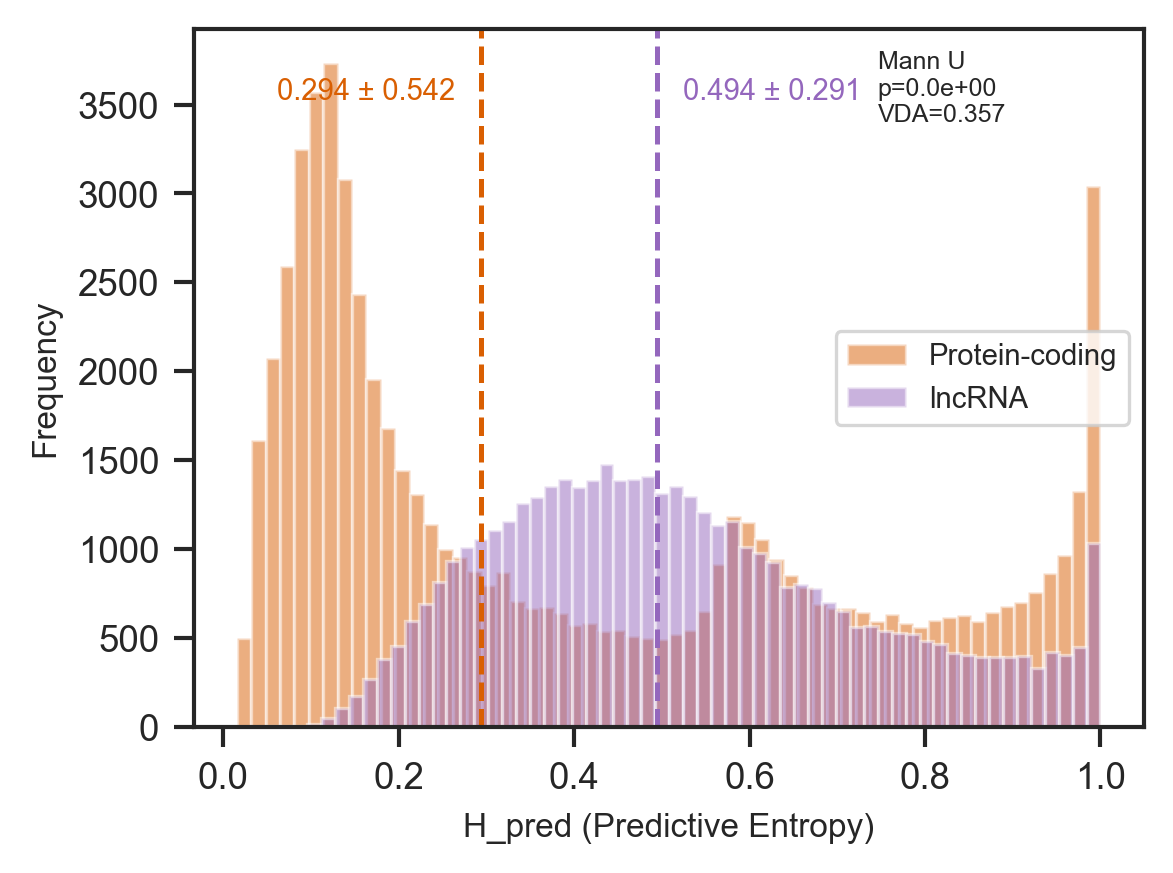

Coding:  median=0.2942, IQR=0.5420
lncRNA:  median=0.4939, IQR=0.2910
Mann-Whitney U  p=0.00e+00, VDA=0.3572


In [ ]:
from scipy.stats import mannwhitneyu as _mwu

pcs  = entropy_df.loc[entropy_df['coding_class'] == 1, 'H_pred']
lncs = entropy_df.loc[entropy_df['coding_class'] == 0, 'H_pred']
pc_iqr  = pcs.quantile(0.75)  - pcs.quantile(0.25)
lnc_iqr = lncs.quantile(0.75) - lncs.quantile(0.25)
u_stat, p_mw = _mwu(pcs, lncs, alternative='two-sided')
vda    = u_stat / (len(pcs) * len(lncs))

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)
ax.hist(pcs,  bins=60, alpha=0.5, label='Protein-coding', color=utils.plotting.COLORS['pc'])
ax.hist(lncs, bins=60, alpha=0.5, label='lncRNA',         color=utils.plotting.COLORS['lnc'])
ax.axvline(pcs.median(),  color=utils.plotting.COLORS['pc'],  linestyle='--', linewidth=1.2)
ax.axvline(lncs.median(), color=utils.plotting.COLORS['lnc'], linestyle='--', linewidth=1.2)
ax.text(pcs.median()  - 0.03, ax.get_ylim()[1] * 0.9,
        f'{pcs.median():.3f} ± {pc_iqr:.3f}',
        color=utils.plotting.COLORS['pc'], ha='right', fontsize=7)
ax.text(lncs.median() + 0.03, ax.get_ylim()[1] * 0.9,
        f'{lncs.median():.3f} ± {lnc_iqr:.3f}',
        color=utils.plotting.COLORS['lnc'], ha='left', fontsize=7)
ax.text(0.72, 0.97,
        f'Mann U\np={p_mw:.1e}\nVDA={vda:.3f}',
        transform=ax.transAxes, fontsize=6, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
ax.set_xlabel('H_pred (Predictive Entropy)', fontsize=8)
ax.set_ylabel('Frequency', fontsize=8)
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'hist_H_pred_by_class.pdf', dpi=300, format='pdf')
plt.savefig(FIGURE_DIR / 'hist_H_pred_by_class.png', dpi=300)
plt.show()

print(f'Coding:  median={pcs.median():.4f}, IQR={pc_iqr:.4f}')
print(f'lncRNA:  median={lncs.median():.4f}, IQR={lnc_iqr:.4f}')
print(f'Mann-Whitney U  p={p_mw:.2e}, VDA={vda:.4f}')

---
## Strategy 1: Overall entropy thresholds (10th / 90th percentile)

Transcripts are split into **low** (H_pred < 10th percentile), **middle**, and **high** groups
using percentile cutoffs computed on the entire dataset (both classes together).
The **high** group requires H_pred ≥ 90th percentile **and** I_BALD ≥ 90th percentile.

In [ ]:
entropy_df["ensemble_pred"] = (probs.mean(axis=1) >= 0.5).astype(int)

In [ ]:
lo_th_hpred = np.percentile(entropy_df['H_pred'], LOW_TH)
hi_th_hpred = np.percentile(entropy_df['H_pred'], HIGH_TH)
hi_th_ibald = np.percentile(entropy_df['I_bald'], HIGH_TH)

entropy_df['s1_group'] = 'middle'
entropy_df.loc[entropy_df['H_pred'] <= lo_th_hpred, 's1_group'] = 'low'
entropy_df.loc[
    (entropy_df['H_pred'] >= hi_th_hpred) & (entropy_df['I_bald'] >= hi_th_ibald),
    's1_group',
] = 'high'

s1_low_idx    = entropy_df[entropy_df['s1_group'] == 'low'].index
s1_high_idx   = entropy_df[entropy_df['s1_group'] == 'high'].index
s1_middle_idx = entropy_df[entropy_df['s1_group'] == 'middle'].index

print(f'Thresholds:  low ≤ H_pred {lo_th_hpred:.4f}')
print(f'             high ≥ H_pred {hi_th_hpred:.4f} AND I_BALD ≥ {hi_th_ibald:.4f}')
print(f'low:    n={len(s1_low_idx):,}')
print(f'middle: n={len(s1_middle_idx):,}')
print(f'high:   n={len(s1_high_idx):,}')

# Overall accuracy
overall_acc = balanced_accuracy_score(
    entropy_df['coding_class'], entropy_df['ensemble_pred'])
print(f'\nOverall balanced accuracy: {overall_acc:.4f}')
for grp in ['low', 'middle', 'high']:
    m = entropy_df['s1_group'] == grp
    a = balanced_accuracy_score(entropy_df.loc[m, 'coding_class'], entropy_df.loc[m, 'ensemble_pred'])
    print(f'  {grp:6s}: {a:.4f}')

Thresholds:  low ≤ H_pred 0.1030
             high ≥ H_pred 0.8951 AND I_BALD ≥ 0.3984
low:    n=11,166
middle: n=96,440
high:   n=4,046

Overall balanced accuracy: 0.9421
  low   : 0.6500
  middle: 0.9472
  high  : 0.6193


### 3.1 Scatter: H_pred vs I_BALD (Strategy 1)

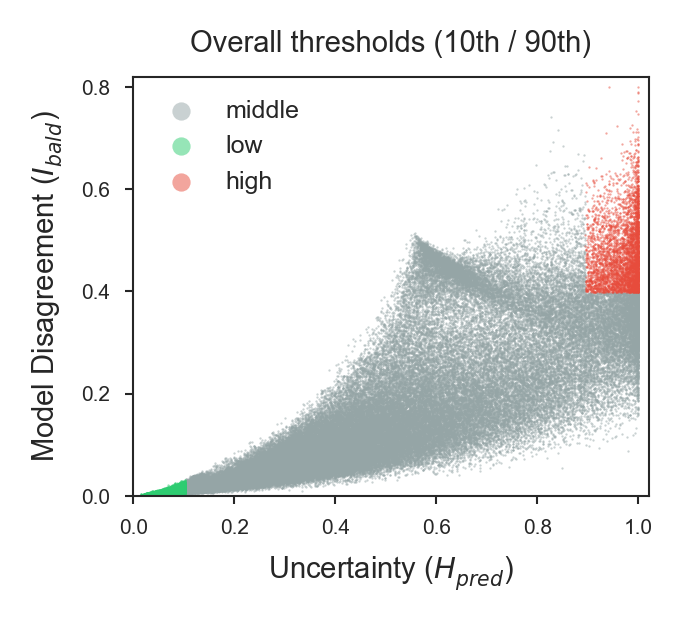

In [ ]:
s1_colors = utils.plotting.COLORS['entropy_class']  # low/other/high
plot_scatter(
    entropy_df,
    group_col='s1_group',
    color_map=s1_colors,
    title=f'Overall thresholds ({LOW_TH}th / {HIGH_TH}th)',
    save_path=FIGURE_DIR / 's1_scatter',
)

### 3.2 Balanced accuracy across threshold range (Strategy 1)

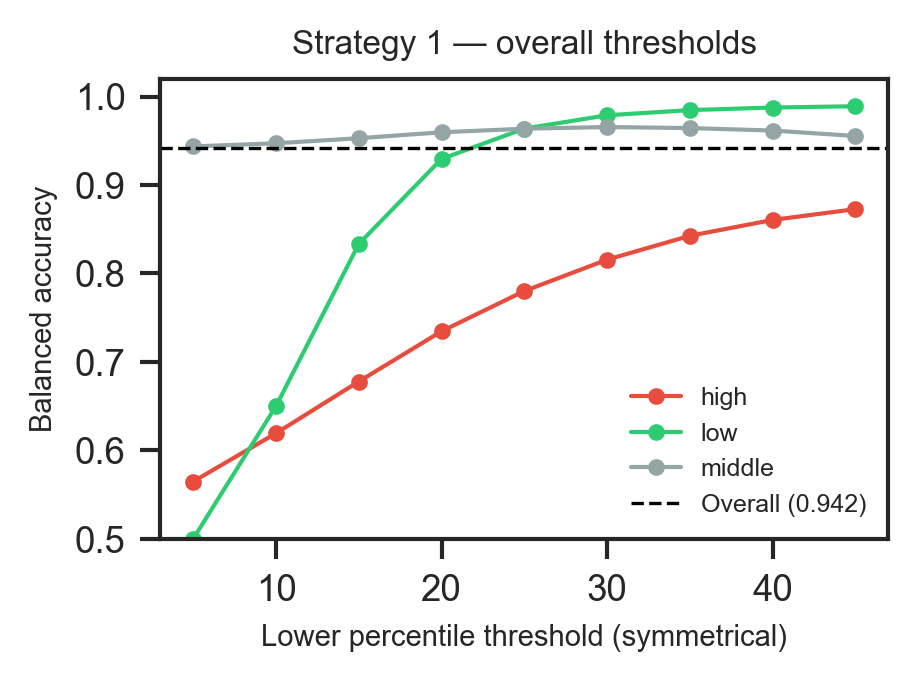

In [ ]:
THRESHOLDS = list(range(5, 46, 5))

s1_acc_df = accuracy_vs_threshold(entropy_df, THRESHOLDS, by_class=False)
plot_accuracy_vs_threshold(
    s1_acc_df,
    overall_acc=overall_acc,
    title='Strategy 1 — overall thresholds',
    save_path=FIGURE_DIR / 's1_accuracy_vs_threshold',
)

### 3.3 Univariate tests (Strategy 1)

── Low vs High entropy (Strategy 1) ──
Dataset: Removing 5 constant features
  Constant features: ['pseudo_ancient_count', 'pseudo_ancient_count_per_kb', 'pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb']
Dataset: Removing 1 constant features
  Constant features: ['te_has_ple']
  MWU: 353/435 significant
  Chi2: 16/23 significant


  Saved -> s1_low_vs_high.[pdf/png]


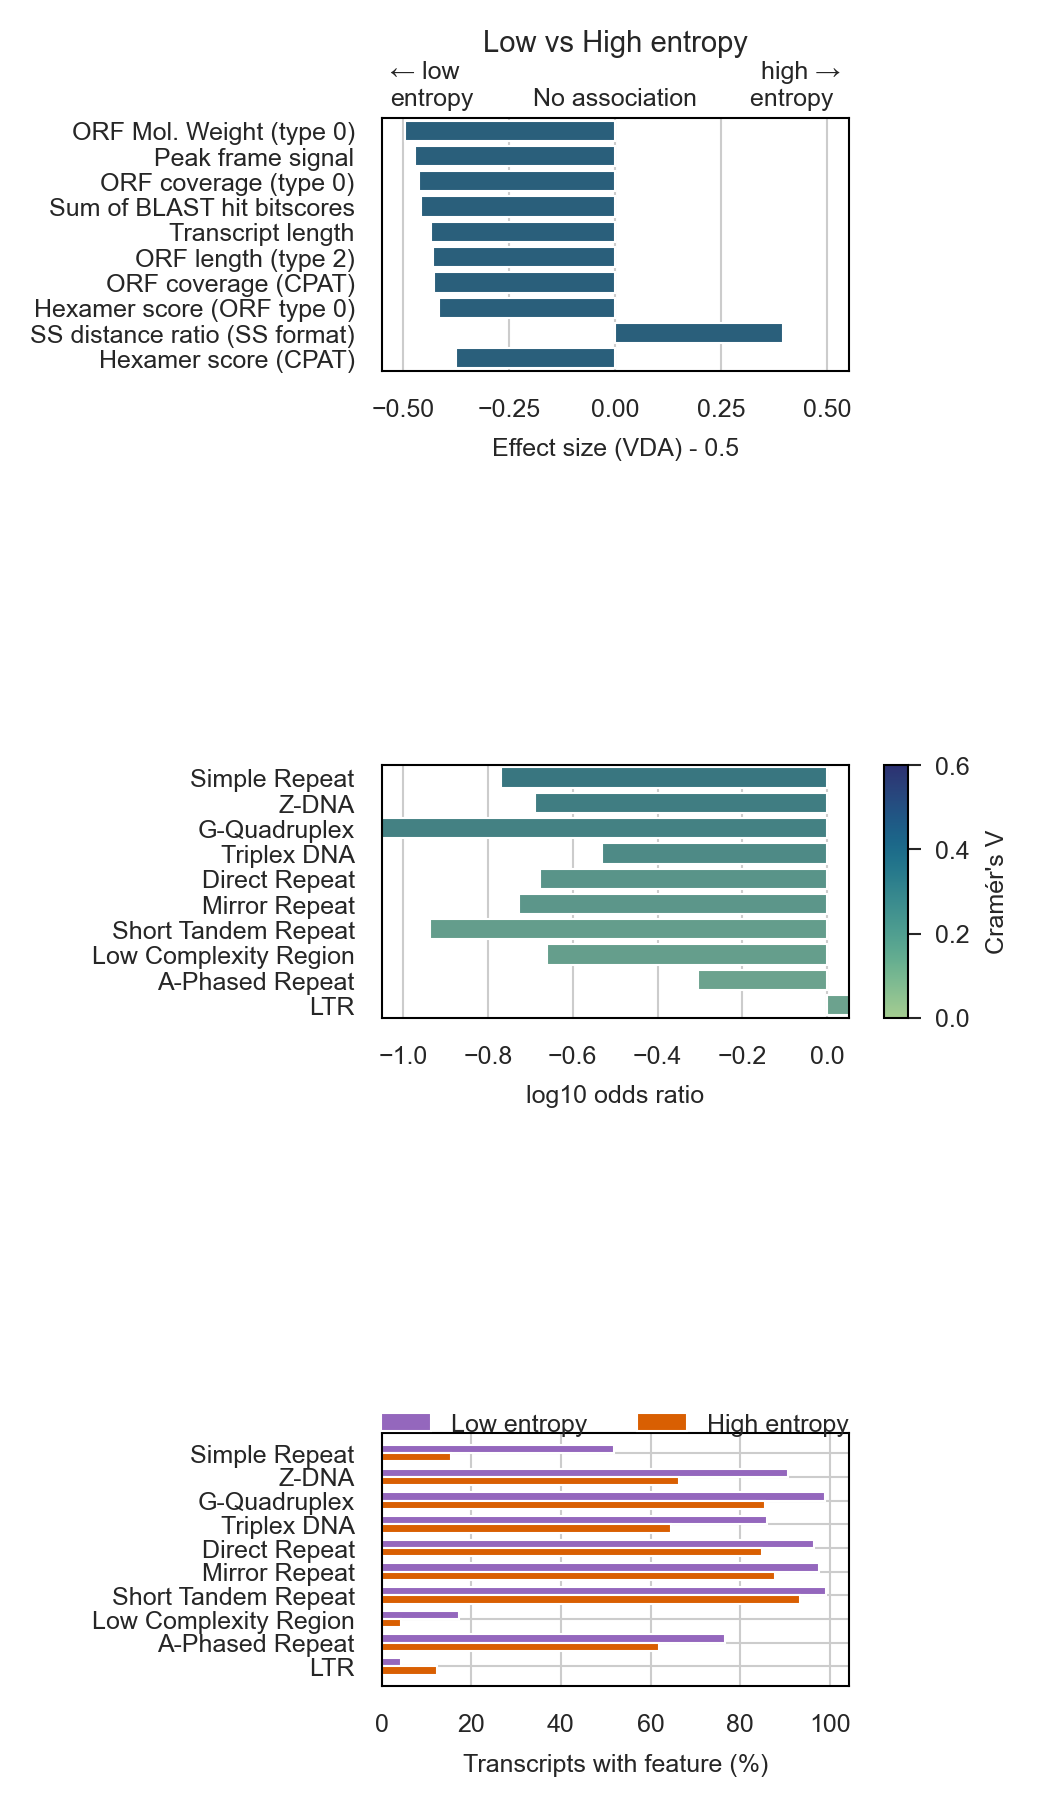

(                             statistic  p_value       vda   abs_vda  \
 feature                                                               
 ORF_T0_MW_lncDC               201247.0      0.0  0.004455  0.495545   
 Signal.Peak_lncfinder        1287322.0      0.0  0.028495  0.471505   
 ORF_T0_coverage_lncDC        1697663.5      0.0  0.037578  0.462422   
 all_Bitscore_plncpro         1915277.0      0.0  0.042394  0.457606   
 RNA_size_feelnc              3038613.5      0.0  0.067259  0.432741   
 ORF_T2_length_lncDC          3156929.0      0.0  0.069878  0.430122   
 ORF_coverage_l_cpat          3282204.5      0.0  0.072651  0.427349   
 Hexamer_score_ORF_T0_lncDC   3867785.0      0.0  0.085613  0.414387   
 SS.Dist.Ratio_lncfinder     40471957.0      0.0  0.895841  0.395841   
 Hexamer_l_cpat               5685083.0      0.0  0.125838  0.374162   
 
                                       test  adj_p  significant  cluster_0.25  \
 feature                                             

In [ ]:
# (1) Low entropy vs high entropy (all transcripts)
print('── Low vs High entropy (Strategy 1) ──')
s1_mannu_lh, s1_chi2_lh = run_stat_tests(
    s1_low_idx, s1_high_idx, scalar_features, cat_features)

plot_top10_features(
    s1_mannu_lh, s1_chi2_lh,
    grp1=s1_low_idx, grp2=s1_high_idx,
    grp1_label='Low entropy', grp2_label='High entropy',
    categorical=cat_features,
    cluster_df=cluster_df, cluster_col=CLUSTER_DIST,
    title='Low vs High entropy',
    save_path=FIGURE_DIR / 's1_low_vs_high',
    xlim_chi2=(-1.05, 0.05),
    chi2_annotation=('high →\nentropy ', '← low\nentropy'),
)

── PC vs lncRNA in LOW entropy (Strategy 1) ──
  PC n=11,156, lncRNA n=10
Dataset: Removing 5 constant features
  Constant features: ['pseudo_ancient_count', 'pseudo_ancient_count_per_kb', 'pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb']


Dataset: Removing 1 constant features
  Constant features: ['te_has_ple']
  MWU: 3/435 significant
  Chi2: 2/23 significant
  Saved -> s1_low_pc_vs_lnc.[pdf/png]


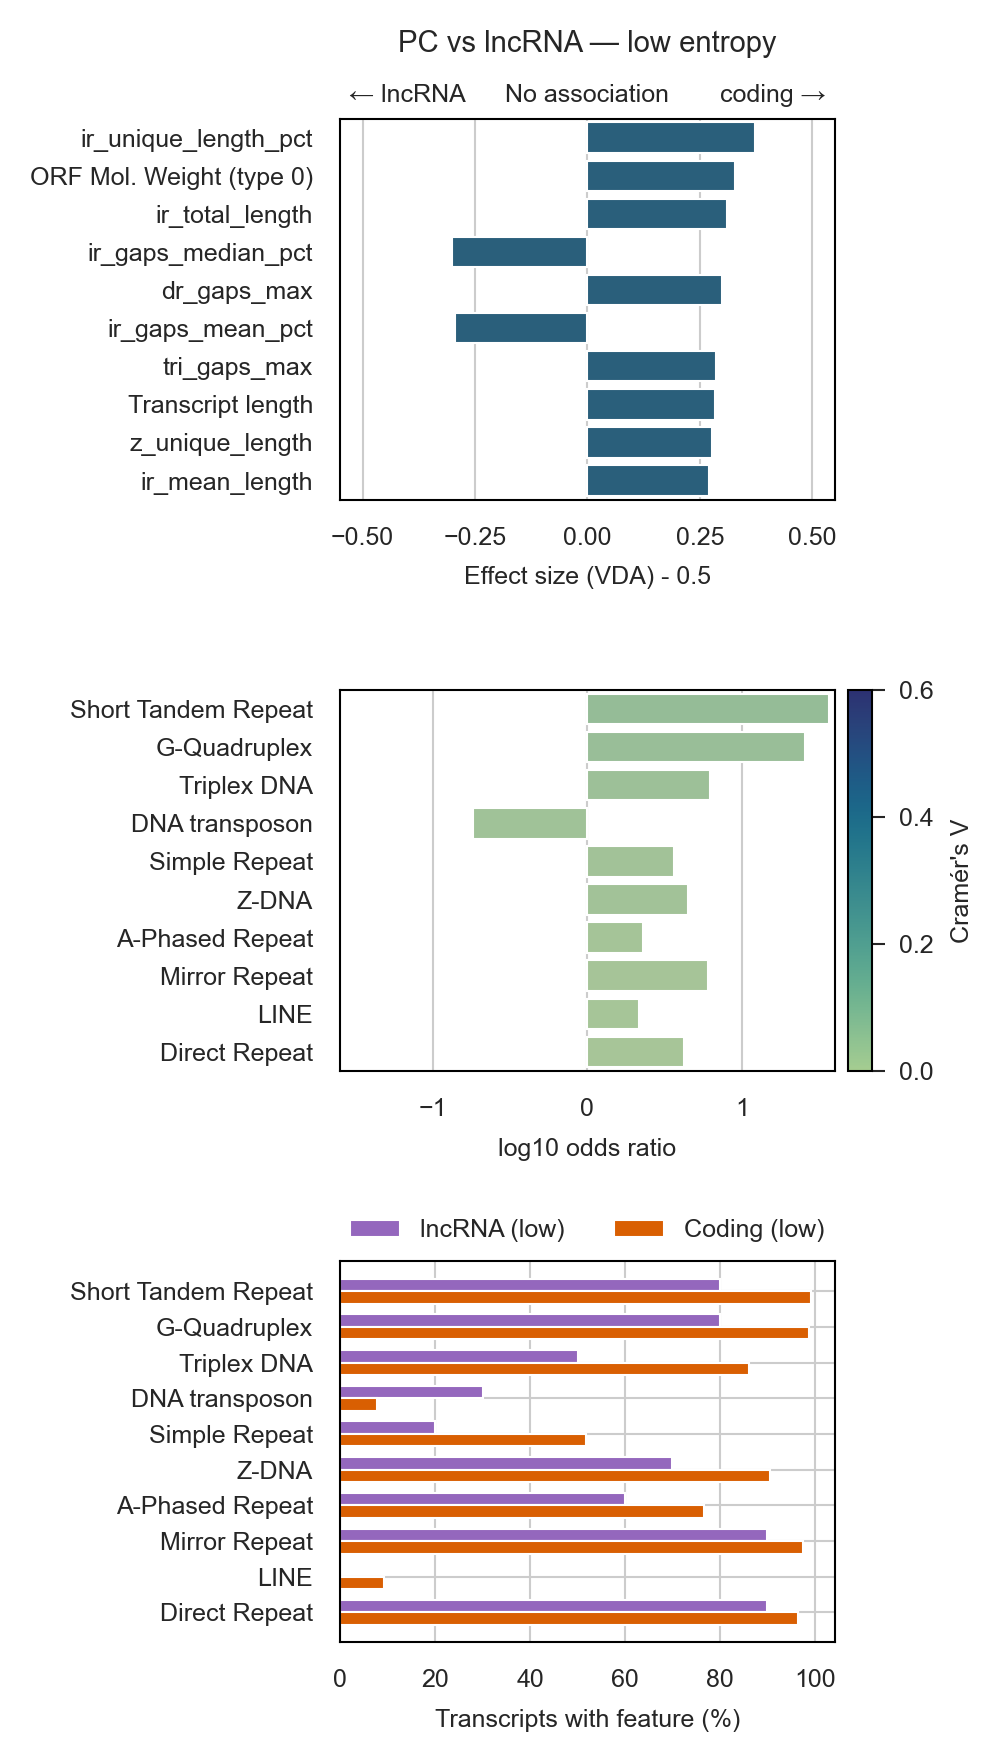

(                      statistic   p_value       vda   abs_vda            test  \
 feature                                                                         
 ir_unique_length_pct    97435.0  0.000043  0.873387  0.373387  Mann-Whitney U   
 ORF_T0_MW_lncDC         92303.0  0.000338  0.827384  0.327384  Mann-Whitney U   
 ir_total_length         90510.0  0.000653  0.811312  0.311312  Mann-Whitney U   
 ir_gaps_median_pct      22199.0  0.000982  0.198987  0.301013  Mann-Whitney U   
 dr_gaps_max             89225.5  0.001029  0.799798  0.299798  Mann-Whitney U   
 ir_gaps_mean_pct        22988.0  0.001289  0.206060  0.293940  Mann-Whitney U   
 tri_gaps_max            87785.5  0.001659  0.786890  0.286890  Mann-Whitney U   
 RNA_size_feelnc         87499.5  0.001852  0.784327  0.284327  Mann-Whitney U   
 z_unique_length         86606.0  0.002472  0.776318  0.276318  Mann-Whitney U   
 ir_mean_length          85965.0  0.003052  0.770572  0.270572  Mann-Whitney U   
 
              

In [ ]:
# (2) PC vs lncRNA within the low entropy group
s1_low_pc  = s1_low_idx.intersection(pc_idx)
s1_low_lnc = s1_low_idx.intersection(lnc_idx)

print('── PC vs lncRNA in LOW entropy (Strategy 1) ──')
print(f'  PC n={len(s1_low_pc):,}, lncRNA n={len(s1_low_lnc):,}')
s1_mannu_low, s1_chi2_low = run_stat_tests(
    s1_low_lnc, s1_low_pc, scalar_features, cat_features)

plot_top10_features(
    s1_mannu_low, s1_chi2_low,
    grp1=s1_low_lnc, grp2=s1_low_pc,
    grp1_label='lncRNA (low)', grp2_label='Coding (low)',
    categorical=cat_features,
    cluster_df=cluster_df, cluster_col=CLUSTER_DIST,
    title='PC vs lncRNA — low entropy',
    save_path=FIGURE_DIR / 's1_low_pc_vs_lnc',
    xlim_chi2=(-1.6, 1.6),
    chi2_annotation=('coding →', '← lncRNA'),
)

── PC vs lncRNA in HIGH entropy (Strategy 1) ──
  PC n=3,015, lncRNA n=1,031
Dataset: Removing 9 constant features
  Constant features: ['pseudo_ancient_count', 'pseudo_ancient_count_per_kb', 'pseudo_scrna_count', 'pseudo_scrna_count_per_kb', 'pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb', 'te_rc_count', 'te_rc_count_per_kb']


Dataset: Removing 3 constant features
  Constant features: ['te_has_ple', 'te_has_rc', 'pseudo_has_scrna']
  MWU: 230/431 significant
  Chi2: 8/21 significant
  Saved -> s1_high_pc_vs_lnc.[pdf/png]


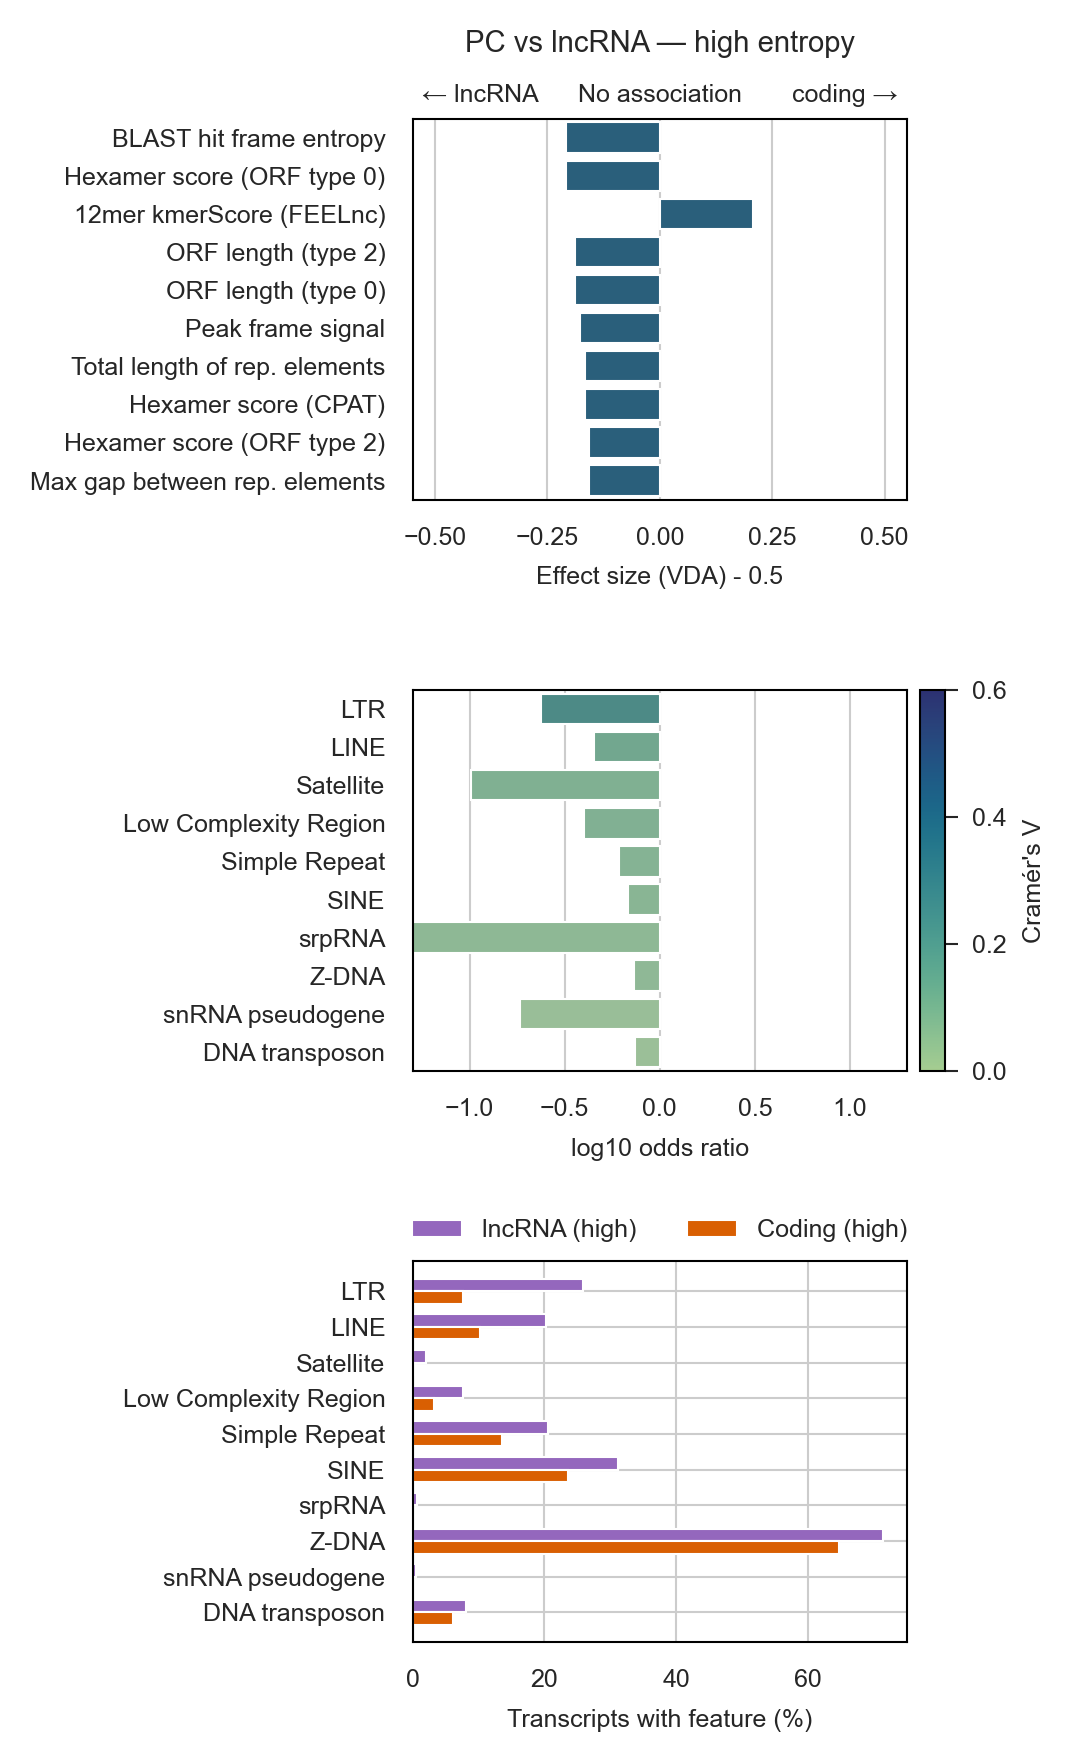

(                            statistic        p_value       vda   abs_vda  \
 feature                                                                    
 all_Frame_Entropy_plncpro    902717.5  3.876764e-150  0.290406  0.209594   
 Hexamer_score_ORF_T0_lncDC   905299.5   2.348685e-89  0.291237  0.208763   
 kmerScore_12mer_feelnc      2197375.0   8.406787e-88  0.706900  0.206900   
 ORF_T2_length_lncDC          967180.5   1.792565e-73  0.311144  0.188856   
 ORF_T0_length_lncDC          969872.5   8.072818e-73  0.312010  0.187990   
 Signal.Peak_lncfinder       1005093.0   1.615404e-64  0.323341  0.176659   
 global_rm_total_length      1034992.0   1.632131e-64  0.332959  0.167041   
 Hexamer_l_cpat              1037933.0   3.036398e-57  0.333905  0.166095   
 Hexamer_score_ORF_T2_lncDC  1062948.0   5.303465e-52  0.341953  0.158047   
 global_gaps_max             1064200.0   1.139060e-57  0.342355  0.157645   
 
                                       test          adj_p  significant  \

In [ ]:
# (3) PC vs lncRNA within the high entropy group
s1_high_pc  = s1_high_idx.intersection(pc_idx)
s1_high_lnc = s1_high_idx.intersection(lnc_idx)

print('── PC vs lncRNA in HIGH entropy (Strategy 1) ──')
print(f'  PC n={len(s1_high_pc):,}, lncRNA n={len(s1_high_lnc):,}')
s1_mannu_high, s1_chi2_high = run_stat_tests(
    s1_high_lnc, s1_high_pc, scalar_features, cat_features)

plot_top10_features(
    s1_mannu_high, s1_chi2_high,
    grp1=s1_high_lnc, grp2=s1_high_pc,
    grp1_label='lncRNA (high)', grp2_label='Coding (high)',
    categorical=cat_features,
    cluster_df=cluster_df, cluster_col=CLUSTER_DIST,
    title='PC vs lncRNA — high entropy',
    save_path=FIGURE_DIR / 's1_high_pc_vs_lnc',
    xlim_chi2=(-1.3, 1.3),
    chi2_annotation=('coding →', '← lncRNA'),
)

---
## Strategy 2: Class-separated entropy thresholds (10th / 90th percentile per class)

Percentile cutoffs are applied **separately** within each biotype (coding / lncRNA),
so each class contributes equally to the low and high entropy groups.
The **high** group requires H_pred ≥ 90th percentile **and** I_BALD ≥ 90th percentile (both computed per class).

In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, f1_score

true_label = entropy_df["coding_class"]
ensemble_pred = entropy_df["ensemble_pred"]
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    true_label, ensemble_pred, average="macro", zero_division=0
)

metrics_macro = pd.Series({
    "accuracy": accuracy_score(true_label, ensemble_pred),
    "balanced_accuracy": balanced_accuracy_score(true_label, ensemble_pred),
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
})

print(metrics_macro.to_string(float_format=lambda x: f"{x:.4f}"))

accuracy            0.9397
balanced_accuracy   0.9421
macro_precision     0.9351
macro_recall        0.9421
macro_f1            0.9380


In [ ]:
entropy_df['s2_group'] = 'middle'

for biotype in ['coding', 'lncRNA']:
    mask  = entropy_df['biotype'] == biotype
    lo_bt = np.percentile(entropy_df.loc[mask, 'H_pred'], LOW_TH)
    hi_bt_hpred = np.percentile(entropy_df.loc[mask, 'H_pred'], HIGH_TH)
    hi_bt_ibald = np.percentile(entropy_df.loc[mask, 'I_bald'], HIGH_TH)
    entropy_df.loc[mask & (entropy_df['H_pred'] <= lo_bt), 's2_group'] = f'low_{biotype}'
    entropy_df.loc[
        mask & (entropy_df['H_pred'] >= hi_bt_hpred) & (entropy_df['I_bald'] >= hi_bt_ibald),
        's2_group',
    ] = f'high_{biotype}'
    print(f'{biotype}: low ≤ H_pred {lo_bt:.4f}, '
          f'high ≥ H_pred {hi_bt_hpred:.4f} AND I_BALD ≥ {hi_bt_ibald:.4f}')

s2_low_pc   = entropy_df[entropy_df['s2_group'] == 'low_coding'].index
s2_high_pc  = entropy_df[entropy_df['s2_group'] == 'high_coding'].index
s2_low_lnc  = entropy_df[entropy_df['s2_group'] == 'low_lncRNA'].index
s2_high_lnc = entropy_df[entropy_df['s2_group'] == 'high_lncRNA'].index

# Combined low/high groups (merging both classes)
s2_low_all  = s2_low_pc.union(s2_low_lnc)
s2_high_all = s2_high_pc.union(s2_high_lnc)

print(f'\nlow_coding: n={len(s2_low_pc):,}, high_coding: n={len(s2_high_pc):,}')
print(f'low_lncRNA: n={len(s2_low_lnc):,}, high_lncRNA: n={len(s2_high_lnc):,}')
print(f'combined low: n={len(s2_low_all):,}, combined high: n={len(s2_high_all):,}')

for grp, idx in [('low_coding', s2_low_pc), ('high_coding', s2_high_pc),
                  ('low_lncRNA', s2_low_lnc), ('high_lncRNA', s2_high_lnc)]:
    acc = balanced_accuracy_score(
        entropy_df.loc[idx, 'coding_class'], entropy_df.loc[idx, 'ensemble_pred'])
    print(f'  {grp:15s}: acc={acc:.4f}')

coding: low ≤ H_pred 0.0803, high ≥ H_pred 0.9251 AND I_BALD ≥ 0.4273
lncRNA: low ≤ H_pred 0.2712, high ≥ H_pred 0.8438 AND I_BALD ≥ 0.3144

low_coding: n=6,638, high_coding: n=1,974
low_lncRNA: n=4,528, high_lncRNA: n=2,587
combined low: n=11,166, combined high: n=4,561
  low_coding     : acc=1.0000
  high_coding    : acc=0.6261
  low_lncRNA     : acc=0.9655
  high_lncRNA    : acc=0.6908


### 4.1 Scatter: H_pred vs I_BALD (Strategy 2)

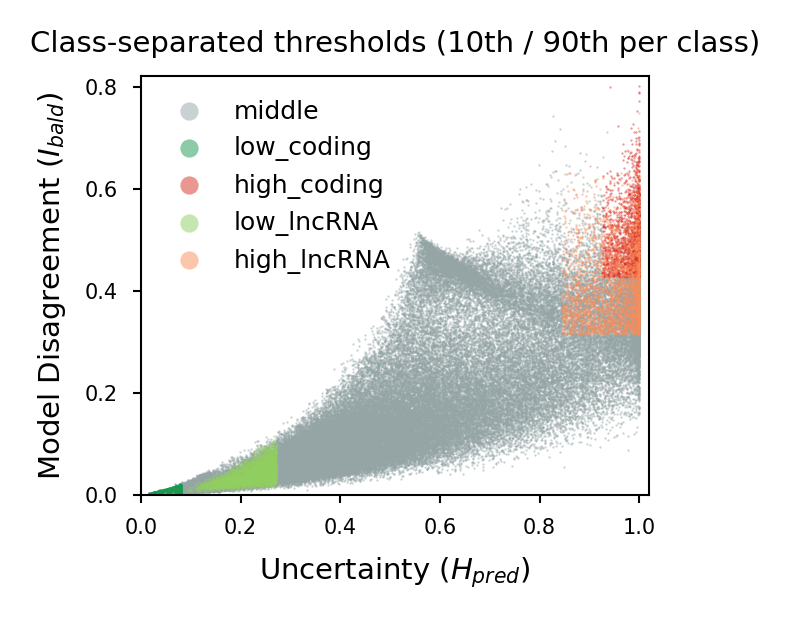

In [ ]:
s2_colors = {
    'low_coding':   '#1a9850',  # dark green
    'high_coding':  '#d73027',  # dark red
    'low_lncRNA':   '#91cf60',  # light green
    'high_lncRNA':  '#fc8d59',  # light red / orange
    'middle':       '#95a5a6',
}
plot_scatter(
    entropy_df,
    group_col='s2_group',
    color_map=s2_colors,
    title=f'Class-separated thresholds ({LOW_TH}th / {HIGH_TH}th per class)',
    save_path=FIGURE_DIR / 's2_scatter',
)

### 4.2 Balanced accuracy across threshold range (Strategy 2)

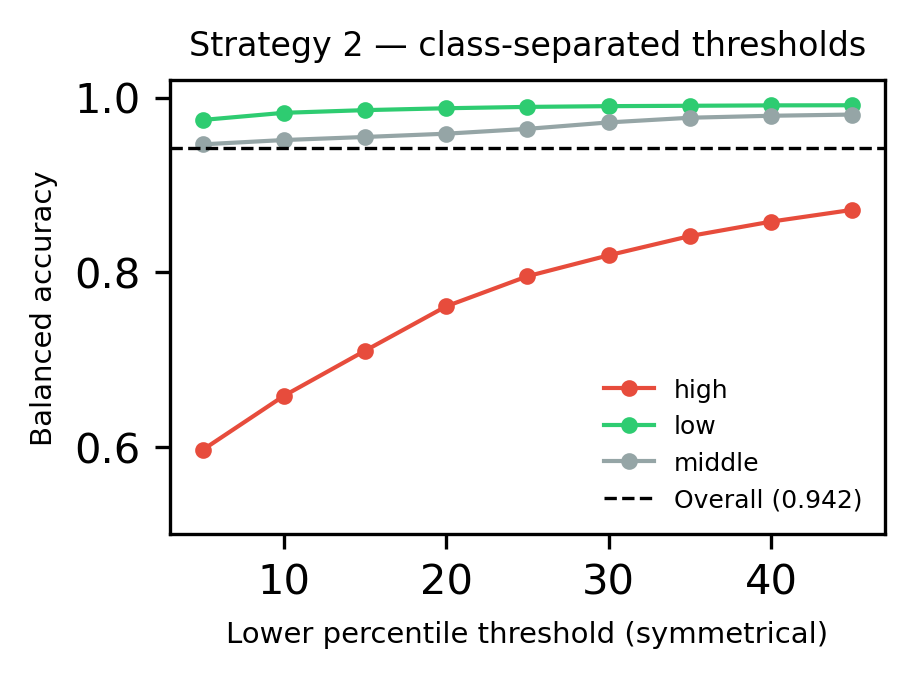

In [ ]:
s2_acc_df = accuracy_vs_threshold(entropy_df, THRESHOLDS, by_class=True)
plot_accuracy_vs_threshold(
    s2_acc_df,
    overall_acc=overall_acc,
    title='Strategy 2 — class-separated thresholds',
    save_path=FIGURE_DIR / 's2_accuracy_vs_threshold',
)

### 4.3 Univariate tests (Strategy 2)

── (low_pc + low_lnc) vs (high_pc + high_lnc) — Strategy 2 ──
Dataset: Removing 3 constant features
  Constant features: ['pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb']
Dataset: Removing 1 constant features
  Constant features: ['te_has_ple']
  MWU: 331/437 significant
  Chi2: 15/23 significant
  Saved -> s2_low_vs_high_combined.[pdf/png]


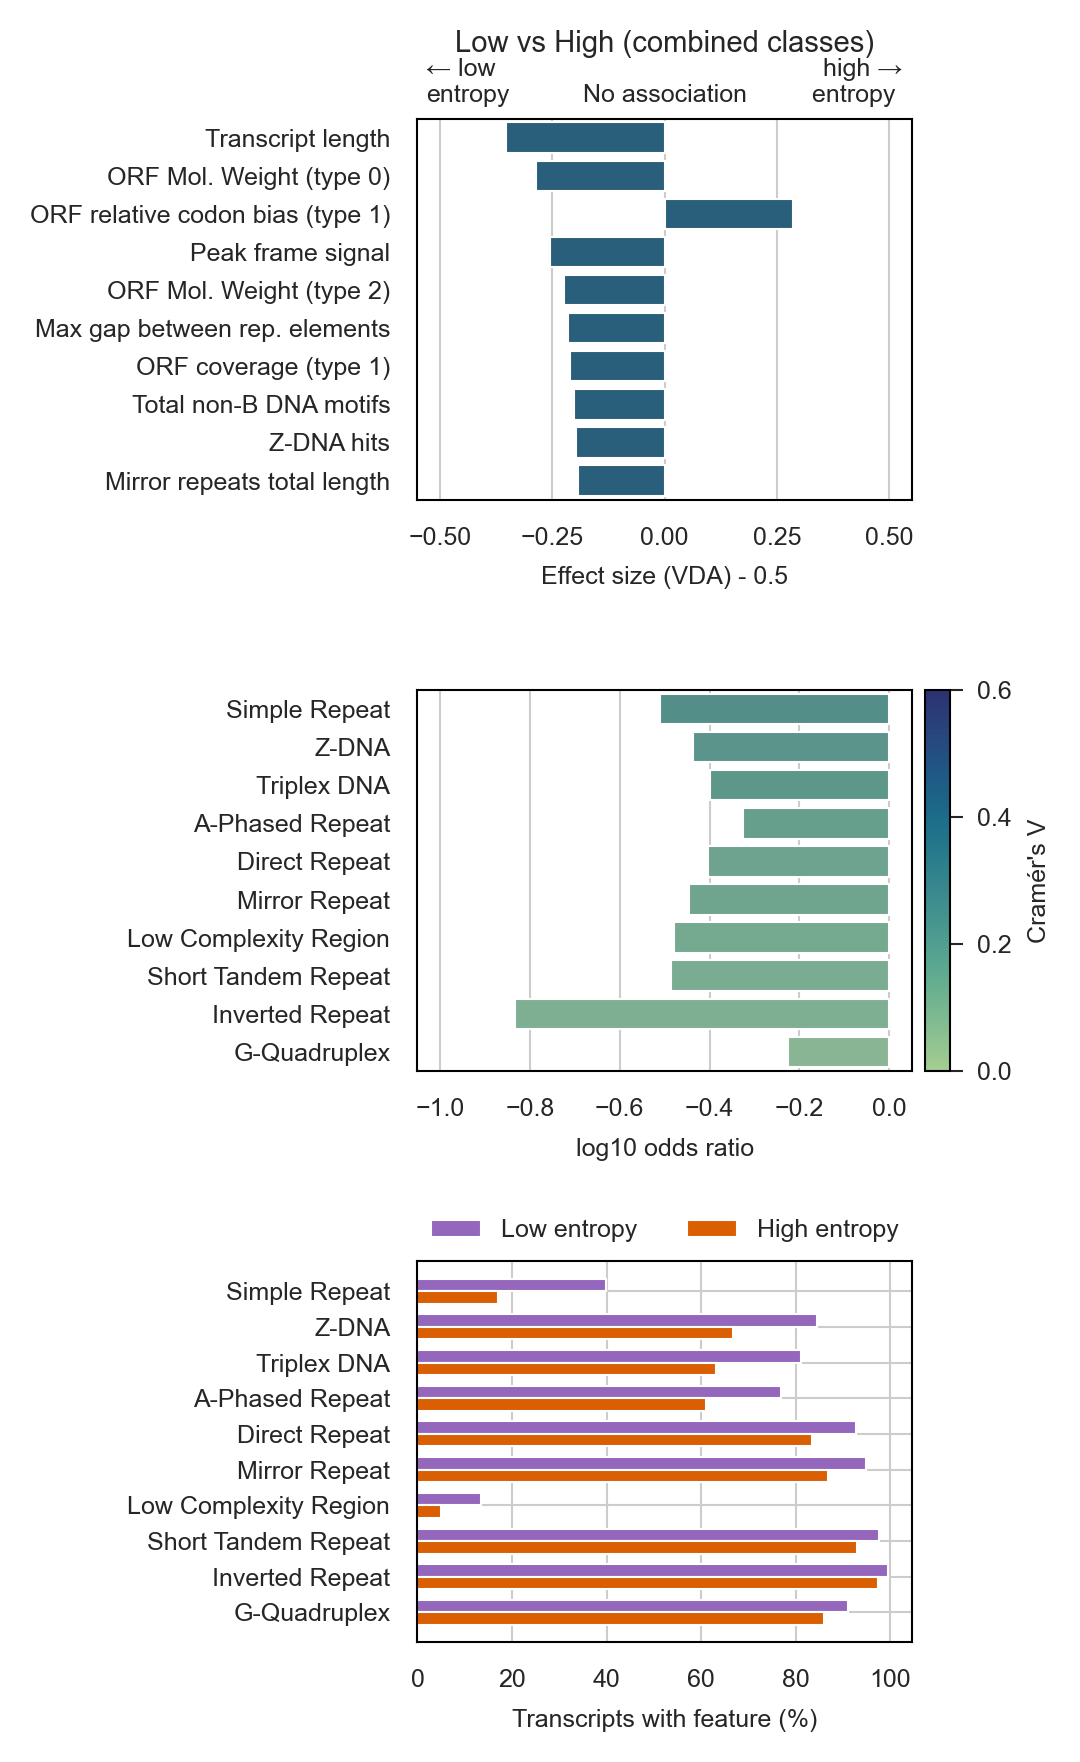

(                        statistic  p_value       vda   abs_vda  \
 feature                                                          
 RNA_size_feelnc         7431779.0      0.0  0.145927  0.354073   
 ORF_T0_MW_lncDC        10885077.5      0.0  0.213734  0.286266   
 RCB_T1_lncDC           39952044.0      0.0  0.784479  0.284479   
 Signal.Peak_lncfinder  12472493.0      0.0  0.244904  0.255096   
 ORF_T2_MW_lncDC        14039548.5      0.0  0.275674  0.224326   
 global_gaps_max        14527154.5      0.0  0.285248  0.214752   
 ORF_T1_coverage_lncDC  14736094.0      0.0  0.289351  0.210649   
 total_nonb_count       15230547.0      0.0  0.299060  0.200940   
 z_hit_count            15365374.5      0.0  0.301707  0.198293   
 mr_unique_length       15594962.5      0.0  0.306215  0.193785   
 
                                  test  adj_p  significant  cluster_0.25  \
 feature                                                                   
 RNA_size_feelnc        Mann-Whitney U    

In [ ]:
# (1a) Low vs High entropy — COMBINED (low_pc + low_lnc vs high_pc + high_lnc)
print('── (low_pc + low_lnc) vs (high_pc + high_lnc) — Strategy 2 ──')
s2_mannu_comb, s2_chi2_comb = run_stat_tests(
    s2_low_all, s2_high_all, scalar_features, cat_features)

plot_top10_features(
    s2_mannu_comb, s2_chi2_comb,
    grp1=s2_low_all, grp2=s2_high_all,
    grp1_label='Low entropy', grp2_label='High entropy',
    categorical=cat_features,
    cluster_df=cluster_df, cluster_col=CLUSTER_DIST,
    title='Low vs High (combined classes)',
    save_path=FIGURE_DIR / 's2_low_vs_high_combined',
    xlim_chi2=(-1.05, 0.05),
    chi2_annotation=('high →\nentropy ', '← low\nentropy'),
)

── Low vs High entropy within coding (Strategy 2) ──
Dataset: Removing 9 constant features
  Constant features: ['pseudo_ancient_count', 'pseudo_ancient_count_per_kb', 'pseudo_rrna_count', 'pseudo_rrna_count_per_kb', 'pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb', 'te_rc_count', 'te_rc_count_per_kb']


Dataset: Removing 3 constant features
  Constant features: ['te_has_ple', 'te_has_rc', 'pseudo_has_rrna']
  MWU: 353/431 significant
  Chi2: 14/21 significant
  Saved -> s2_coding_low_vs_high.[pdf/png]


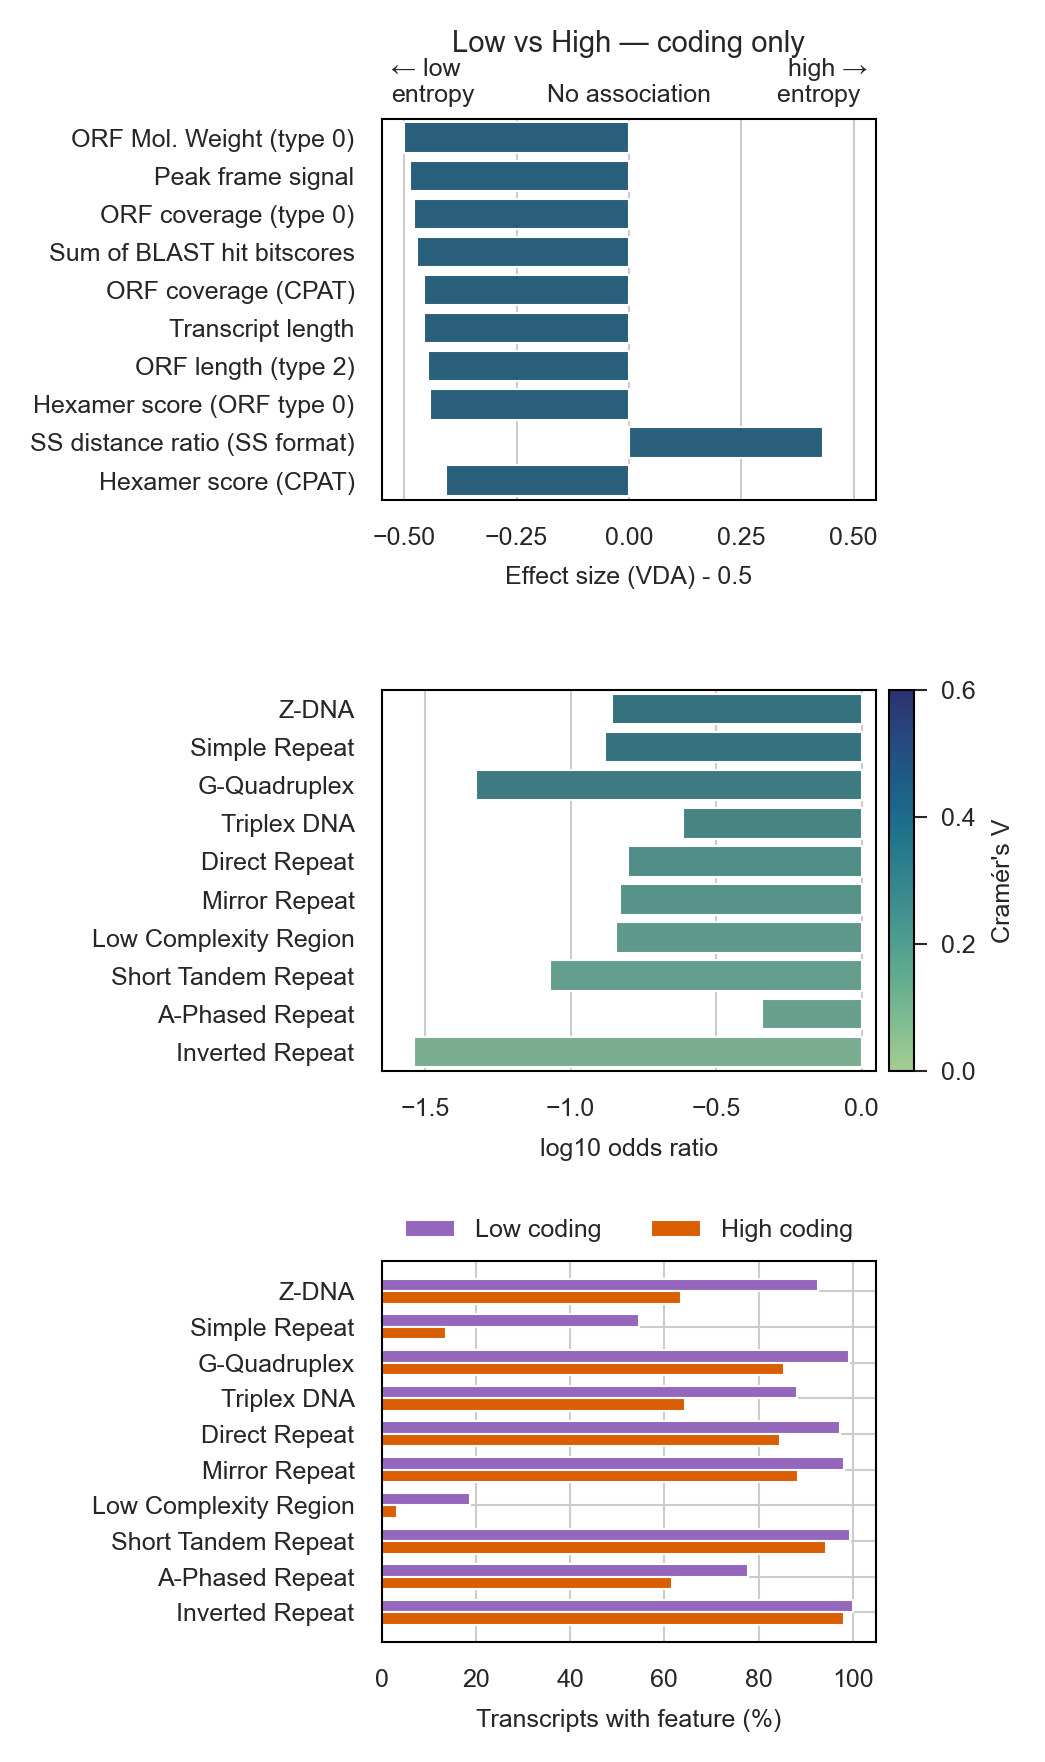

(                             statistic  p_value       vda   abs_vda  \
 feature                                                               
 ORF_T0_MW_lncDC                 8146.0      0.0  0.000622  0.499378   
 Signal.Peak_lncfinder         170174.0      0.0  0.012987  0.487013   
 ORF_T0_coverage_lncDC         287239.5      0.0  0.021921  0.478079   
 all_Bitscore_plncpro          381152.5      0.0  0.029088  0.470912   
 ORF_coverage_l_cpat           569538.5      0.0  0.043465  0.456535   
 RNA_size_feelnc               576295.5      0.0  0.043981  0.456019   
 ORF_T2_length_lncDC           684327.5      0.0  0.052225  0.447775   
 Hexamer_score_ORF_T0_lncDC    742806.0      0.0  0.056688  0.443312   
 SS.Dist.Ratio_lncfinder     12197721.0      0.0  0.930881  0.430881   
 Hexamer_l_cpat               1213989.0      0.0  0.092647  0.407353   
 
                                       test  adj_p  significant  cluster_0.25  \
 feature                                             

In [ ]:
# (1b) Low vs High entropy — within coding only
print('── Low vs High entropy within coding (Strategy 2) ──')
s2_mannu_pc, s2_chi2_pc = run_stat_tests(
    s2_low_pc, s2_high_pc, scalar_features, cat_features)

plot_top10_features(
    s2_mannu_pc, s2_chi2_pc,
    grp1=s2_low_pc, grp2=s2_high_pc,
    grp1_label='Low coding', grp2_label='High coding',
    categorical=cat_features,
    cluster_df=cluster_df, cluster_col=CLUSTER_DIST,
    title='Low vs High — coding only',
    save_path=FIGURE_DIR / 's2_coding_low_vs_high',
    xlim_chi2=(-1.65, 0.05),
    chi2_annotation=('high →\nentropy ', '← low\nentropy'),
)

── Low vs High entropy within lncRNA (Strategy 2) ──
Dataset: Removing 3 constant features
  Constant features: ['pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb']


Dataset: Removing 1 constant features
  Constant features: ['te_has_ple']
  MWU: 351/437 significant
  Chi2: 14/23 significant
  Saved -> s2_lncrna_low_vs_high.[pdf/png]


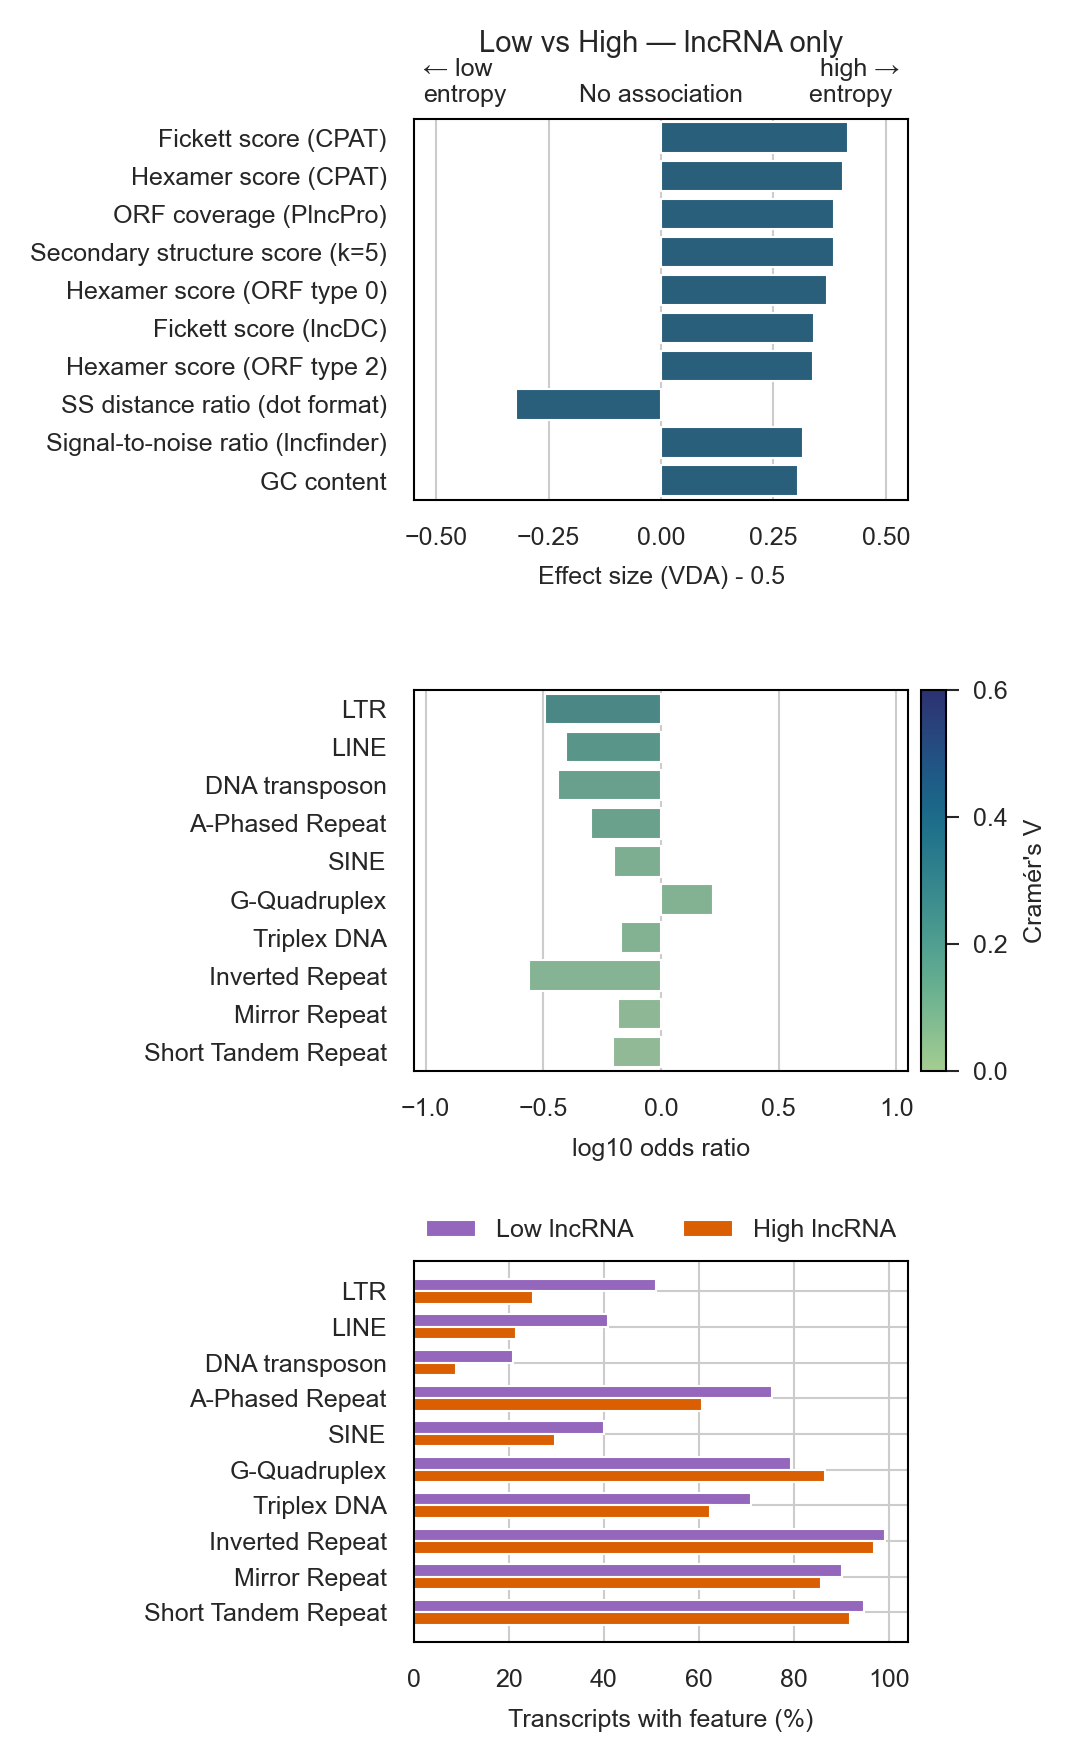

(                             statistic  p_value       vda   abs_vda  \
 feature                                                               
 Fickett_l_cpat              10728456.0      0.0  0.915871  0.415871   
 Hexamer_l_cpat              10610275.0      0.0  0.905782  0.405782   
 orf_coverage_plncpro        10359598.5      0.0  0.884382  0.384382   
 SS_score_k5_lncDC           10352954.0      0.0  0.883815  0.383815   
 Hexamer_score_ORF_T0_lncDC  10171612.5      0.0  0.868334  0.368334   
 Fickett_score_lncDC          9847667.0      0.0  0.840680  0.340680   
 Hexamer_score_ORF_T2_lncDC   9805229.0      0.0  0.837057  0.337057   
 Dot_Dist.Ratio_lncfinder     2088907.0      0.0  0.178327  0.321673   
 SNR_lncfinder                9554940.0      0.0  0.815690  0.315690   
 GC_content_lncDC             9421347.5      0.0  0.804285  0.304285   
 
                                       test  adj_p  significant  cluster_0.25  \
 feature                                             

In [ ]:
# (1c) Low vs High entropy — within lncRNA only
print('── Low vs High entropy within lncRNA (Strategy 2) ──')
s2_mannu_lnc, s2_chi2_lnc = run_stat_tests(
    s2_low_lnc, s2_high_lnc, scalar_features, cat_features)

plot_top10_features(
    s2_mannu_lnc, s2_chi2_lnc,
    grp1=s2_low_lnc, grp2=s2_high_lnc,
    grp1_label='Low lncRNA', grp2_label='High lncRNA',
    categorical=cat_features,
    cluster_df=cluster_df, cluster_col=CLUSTER_DIST,
    title='Low vs High — lncRNA only',
    save_path=FIGURE_DIR / 's2_lncrna_low_vs_high',
    xlim_chi2=(-1.05, 1.05),
    chi2_annotation=('high →\nentropy ', '← low\nentropy'),
)

── PC vs lncRNA in LOW entropy (Strategy 2) ──
  PC n=6,638, lncRNA n=4,528
Dataset: Removing 3 constant features
  Constant features: ['pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb']


Dataset: Removing 1 constant features
  Constant features: ['te_has_ple']
  MWU: 402/437 significant
  Chi2: 18/23 significant
  Saved -> s2_low_pc_vs_lnc.[pdf/png]


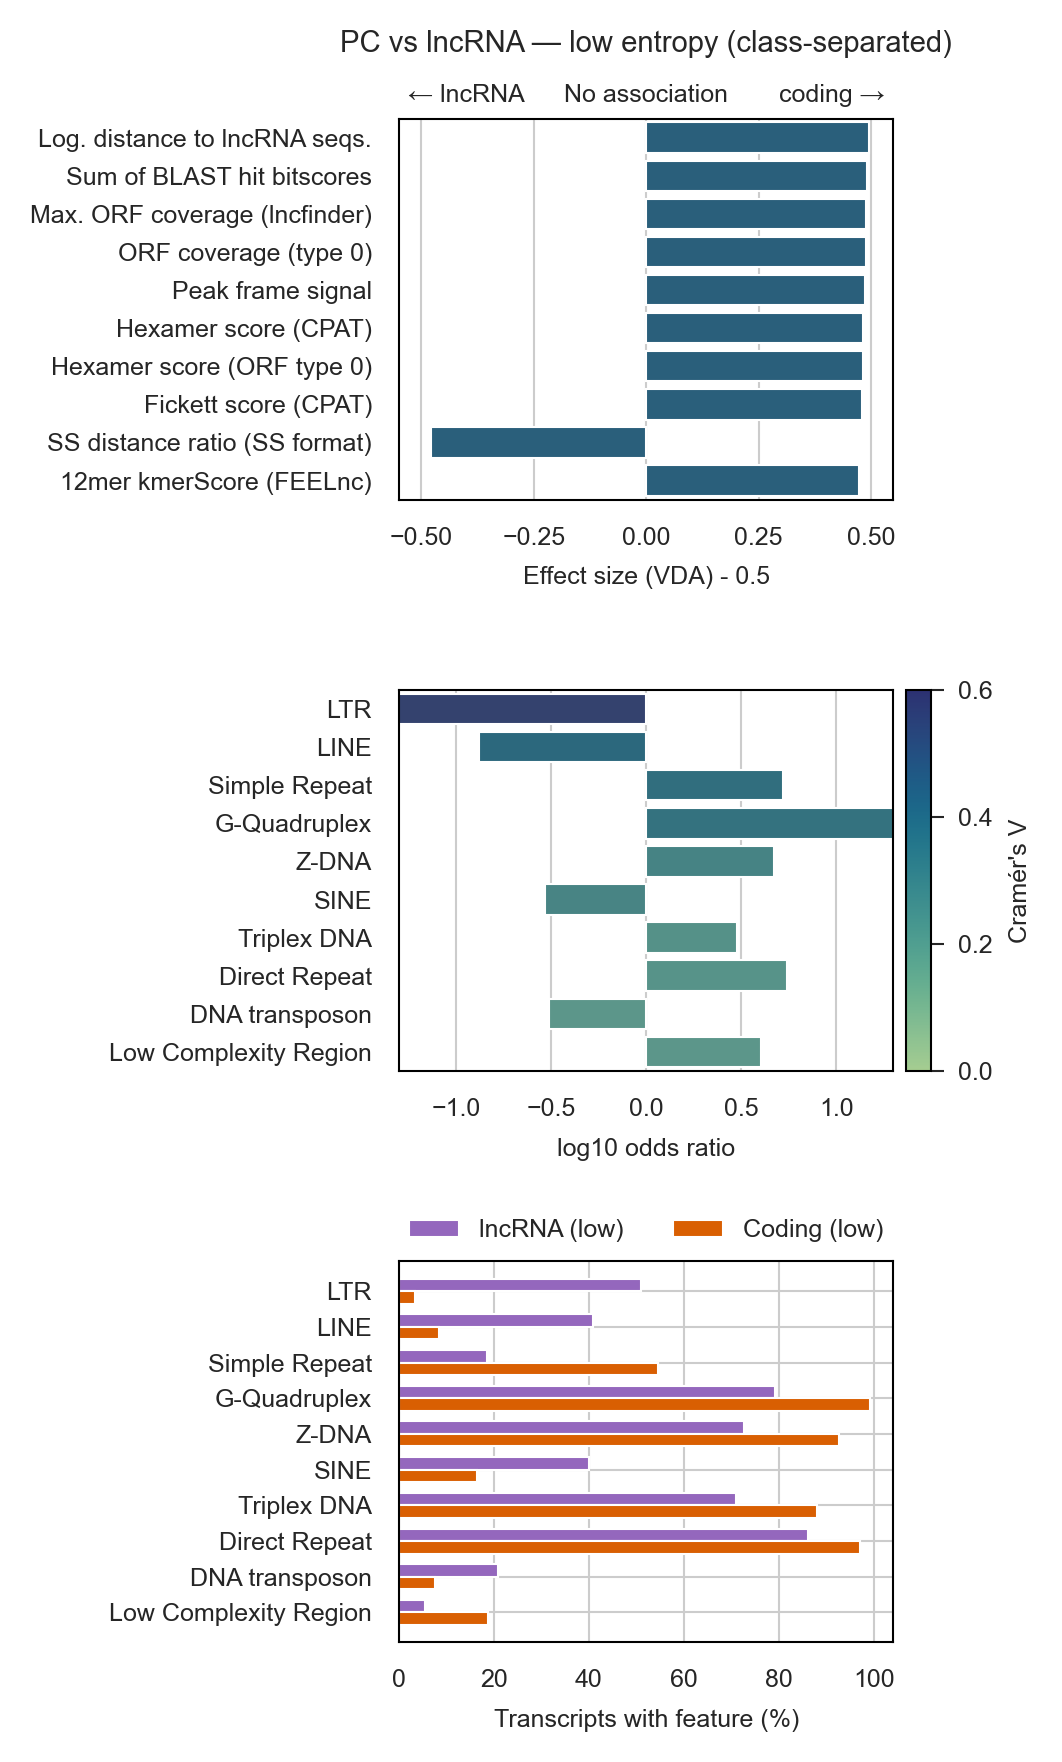

(                             statistic  p_value       vda   abs_vda  \
 feature                                                               
 Seq.lnc.Dist_lncfinder      29949932.0      0.0  0.996442  0.496442   
 all_Bitscore_plncpro        29789812.5      0.0  0.991115  0.491115   
 ORF.Max.Cov_lncfinder       29762213.0      0.0  0.990197  0.490197   
 ORF_T0_coverage_lncDC       29760791.0      0.0  0.990150  0.490150   
 Signal.Peak_lncfinder       29661686.0      0.0  0.986852  0.486852   
 Hexamer_l_cpat              29551932.0      0.0  0.983201  0.483201   
 Hexamer_score_ORF_T0_lncDC  29538146.0      0.0  0.982742  0.482742   
 Fickett_l_cpat              29466520.5      0.0  0.980359  0.480359   
 SS.Dist.Ratio_lncfinder       619831.0      0.0  0.020622  0.479378   
 kmerScore_12mer_feelnc      29275841.5      0.0  0.974015  0.474015   
 
                                       test  adj_p  significant  cluster_0.25  \
 feature                                             

In [ ]:
# (2) PC vs lncRNA within the LOW entropy group (class-separated)
print('── PC vs lncRNA in LOW entropy (Strategy 2) ──')
print(f'  PC n={len(s2_low_pc):,}, lncRNA n={len(s2_low_lnc):,}')
s2_mannu_low_cls, s2_chi2_low_cls = run_stat_tests(
    s2_low_lnc, s2_low_pc, scalar_features, cat_features)

plot_top10_features(
    s2_mannu_low_cls, s2_chi2_low_cls,
    grp1=s2_low_lnc, grp2=s2_low_pc,
    grp1_label='lncRNA (low)', grp2_label='Coding (low)',
    categorical=cat_features,
    cluster_df=cluster_df, cluster_col=CLUSTER_DIST,
    title='PC vs lncRNA — low entropy (class-separated)',
    save_path=FIGURE_DIR / 's2_low_pc_vs_lnc',
    xlim_chi2=(-1.3, 1.3),
    chi2_annotation=('coding →', '← lncRNA'),
)

── PC vs lncRNA in HIGH entropy (Strategy 2) ──
  PC n=1,974, lncRNA n=2,587
Dataset: Removing 7 constant features
  Constant features: ['pseudo_ancient_count', 'pseudo_ancient_count_per_kb', 'pseudo_scrna_count', 'pseudo_scrna_count_per_kb', 'pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb']


Dataset: Removing 2 constant features
  Constant features: ['te_has_ple', 'pseudo_has_scrna']
  MWU: 244/433 significant
  Chi2: 9/22 significant
  Saved -> s2_high_pc_vs_lnc.[pdf/png]


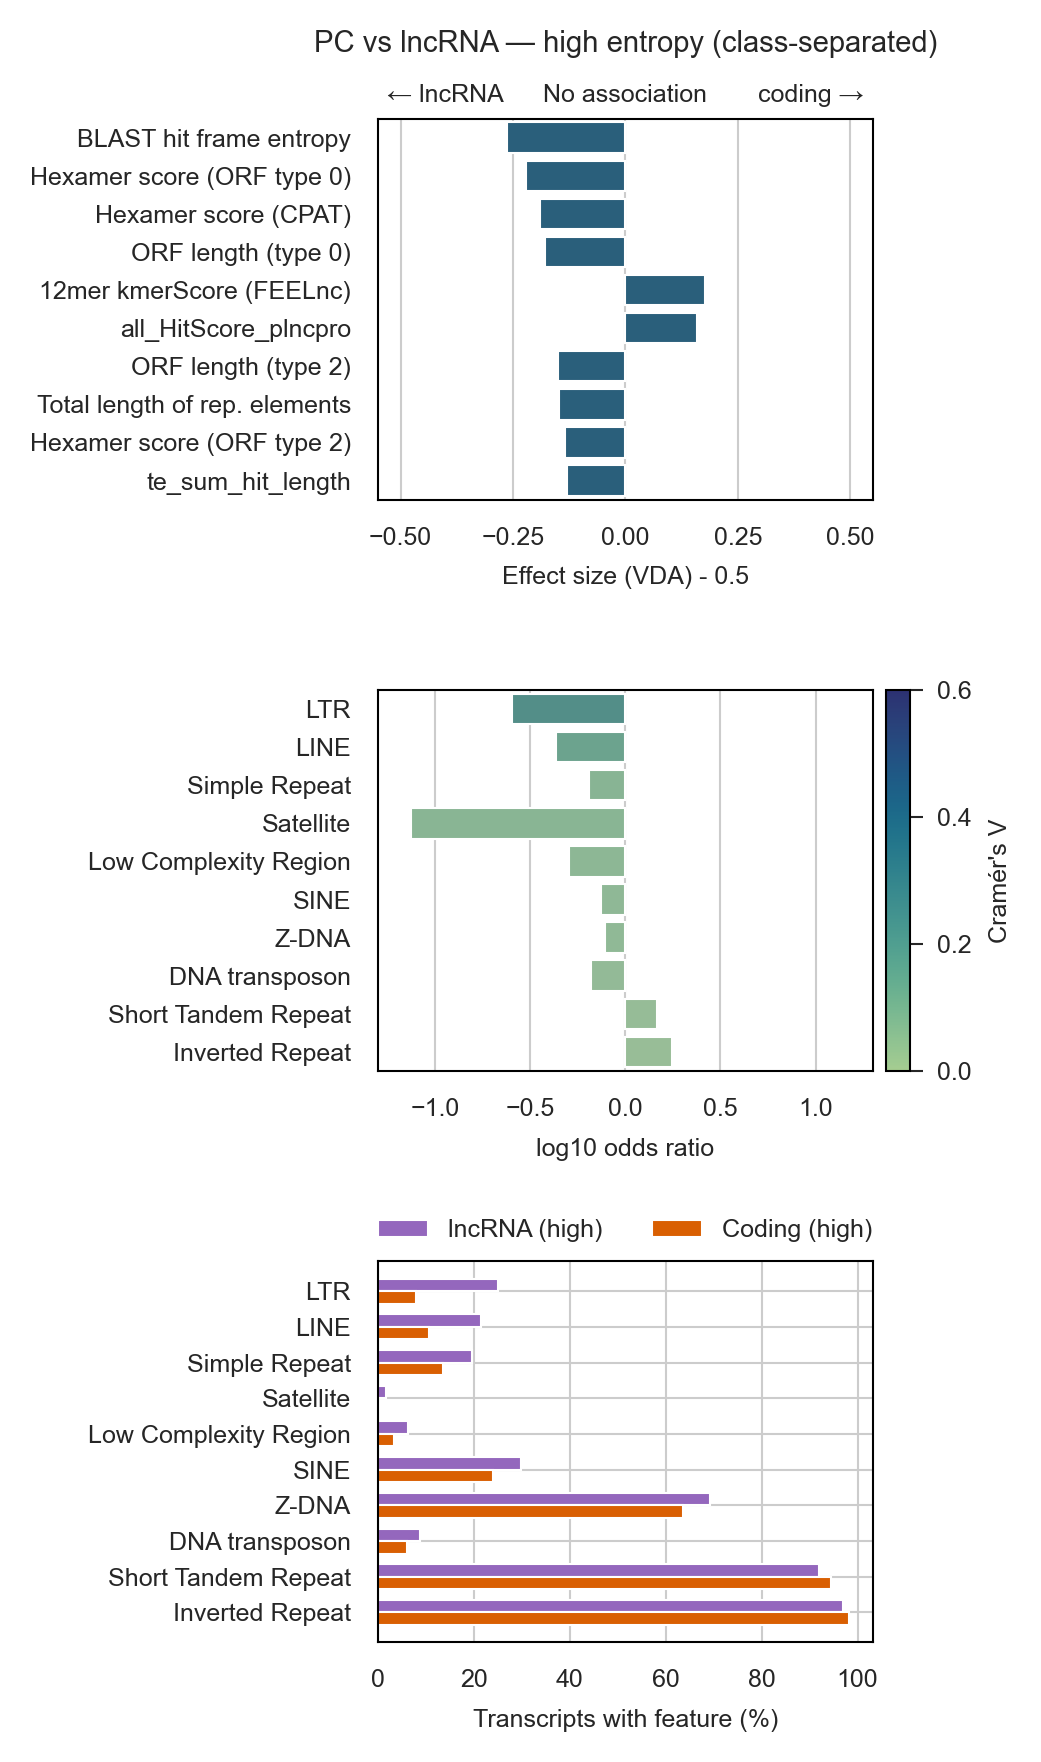

(                            statistic        p_value       vda   abs_vda  \
 feature                                                                    
 all_Frame_Entropy_plncpro   1202709.5  1.271771e-255  0.235514  0.264486   
 Hexamer_score_ORF_T0_lncDC  1425330.0  1.468075e-144  0.279108  0.220892   
 Hexamer_l_cpat              1578395.0  1.715225e-108  0.309081  0.190919   
 ORF_T0_length_lncDC         1639003.0   1.161496e-95  0.320949  0.179051   
 kmerScore_12mer_feelnc      3458820.5   7.739028e-94  0.677305  0.177305   
 all_HitScore_plncpro        3370205.5   4.499491e-77  0.659953  0.159953   
 ORF_T2_length_lncDC         1786011.5   6.245286e-68  0.349736  0.150264   
 global_rm_total_length      1796794.5   1.227332e-70  0.351848  0.148152   
 Hexamer_score_ORF_T2_lncDC  1869541.0   2.546107e-54  0.366093  0.133907   
 te_sum_hit_length           1888243.0   9.206542e-59  0.369755  0.130245   
 
                                       test          adj_p  significant  \

In [ ]:
# (3) PC vs lncRNA within the HIGH entropy group (class-separated)
print('── PC vs lncRNA in HIGH entropy (Strategy 2) ──')
print(f'  PC n={len(s2_high_pc):,}, lncRNA n={len(s2_high_lnc):,}')
s2_mannu_high_cls, s2_chi2_high_cls = run_stat_tests(
    s2_high_lnc, s2_high_pc, scalar_features, cat_features)

plot_top10_features(
    s2_mannu_high_cls, s2_chi2_high_cls,
    grp1=s2_high_lnc, grp2=s2_high_pc,
    grp1_label='lncRNA (high)', grp2_label='Coding (high)',
    categorical=cat_features,
    cluster_df=cluster_df, cluster_col=CLUSTER_DIST,
    title='PC vs lncRNA — high entropy (class-separated)',
    save_path=FIGURE_DIR / 's2_high_pc_vs_lnc',
    xlim_chi2=(-1.3, 1.3),
    chi2_annotation=('coding →', '← lncRNA'),
)